In [1]:
import os
import json
import time
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.linear_model  import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics       import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

import xgboost  as xgb
import lightgbm as lgb

import torch
import torch.nn       as nn
import torch.optim    as optim
from torch.utils.data import DataLoader, TensorDataset

import ray
import ray.data as rd

from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

In [2]:
DATA_PATH = r"D:\1-Oulu-Courses\Distributed-System\Data\edge_logs.ndjson"

OUTPUT_DIR = Path(DATA_PATH).parent / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

MODELS_DIR = Path(DATA_PATH).parent / "models"
MODELS_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi']    = 120

assert Path(DATA_PATH).exists(), f" File not found: {DATA_PATH}"

print(f"   Data file  : {DATA_PATH}")
print(f"   Output dir : {OUTPUT_DIR}")
print(f"   Models dir : {MODELS_DIR}")
print(f"   PyTorch    : {torch.__version__}")
print(f"   Ray        : {ray.__version__}")
print(f"   CUDA GPU   : {'Available' if torch.cuda.is_available() else 'Not available (CPU mode, totally fine)'}")

   Data file  : D:\1-Oulu-Courses\Distributed-System\Data\edge_logs.ndjson
   Output dir : D:\1-Oulu-Courses\Distributed-System\Data\outputs
   Models dir : D:\1-Oulu-Courses\Distributed-System\Data\models
   PyTorch    : 2.7.1+cu118
   Ray        : 2.54.0
   CUDA GPU   : Available


In [3]:
#data load
df = pd.read_json(DATA_PATH, lines=True)

#Parse timestamp as datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

df['hour']        = df['timestamp'].dt.hour
df['date']        = df['timestamp'].dt.date
df['day_of_week'] = df['timestamp'].dt.day_name()

print(f"Loaded {len(df):,} rows and {df.shape[1]} columns")
print(f"   Time range: {df['timestamp'].min()} → {df['timestamp'].max()}")
df.head(3)

Loaded 5,000 rows and 20 columns
   Time range: 2025-01-13 00:00:39.145000+00:00 → 2025-01-15 23:59:20.555000+00:00


,log_version,timestamp,edge_node_id,client_id,session_id,video_id,video_category,segment_number,request_type,cache_hit,response_time_ms,bytes_sent,client_region,protocol,bitrate_requested_kbps,rebuffer_event,status_code,hour,date,day_of_week
0,v1,2025-01-14 21:32:47.171000+00:00,edge-node-03,user_f96fcce0,sess_c1f374194b,video_002,documentaries,112,thumbnail,True,20,180014,FI-HEL,HTTP2,720,False,200,21,2025-01-14,Tuesday
1,v1,2025-01-15 19:14:56.746000+00:00,edge-node-05,user_fcdad5c3,sess_6d59ad621f,video_002,documentaries,76,segment,False,370,271688,FI-OUL,HTTP1.1,1080,False,200,19,2025-01-15,Wednesday
2,v1,2025-01-15 16:42:51.572000+00:00,edge-node-02,user_7b6a74f0,sess_72a24bd7e7,video_006,sports,6,segment,False,440,1126113,SE-STO,HTTP3,4500,False,200,16,2025-01-15,Wednesday


In [5]:
print("Shape")
print(f"  Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")

print("\nNull Values")
print(df.isnull().sum())

print("\nData Types")
print(df.dtypes)

print("\nNumeric Summary")
df.describe()

Shape
  Rows: 5,000  |  Columns: 20

Null Values
log_version               0
timestamp                 0
edge_node_id              0
client_id                 0
session_id                0
video_id                  0
video_category            0
segment_number            0
request_type              0
cache_hit                 0
response_time_ms          0
bytes_sent                0
client_region             0
protocol                  0
bitrate_requested_kbps    0
rebuffer_event            0
status_code               0
hour                      0
date                      0
day_of_week               0
dtype: int64

Data Types
log_version                               str
timestamp                 datetime64[us, UTC]
edge_node_id                              str
client_id                                 str
session_id                                str
video_id                                  str
video_category                            str
segment_number                          int6

,segment_number,response_time_ms,bytes_sent,bitrate_requested_kbps,status_code,hour
count,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000
mean,59.931000,118.104400,7.194793e+05,2875.292000,205.427000,15.518600
std,50.073755,128.727355,6.813929e+05,2713.170502,38.363658,6.857978
min,1.000000,5.000000,8.107200e+04,360.000000,200.000000,0.000000
25%,16.000000,27.000000,1.786500e+05,720.000000,200.000000,10.000000
50%,49.000000,50.000000,2.962320e+05,1080.000000,200.000000,18.000000
75%,94.000000,195.250000,1.131762e+06,4500.000000,200.000000,21.000000
max,196.000000,450.000000,2.199226e+06,8000.000000,503.000000,23.000000


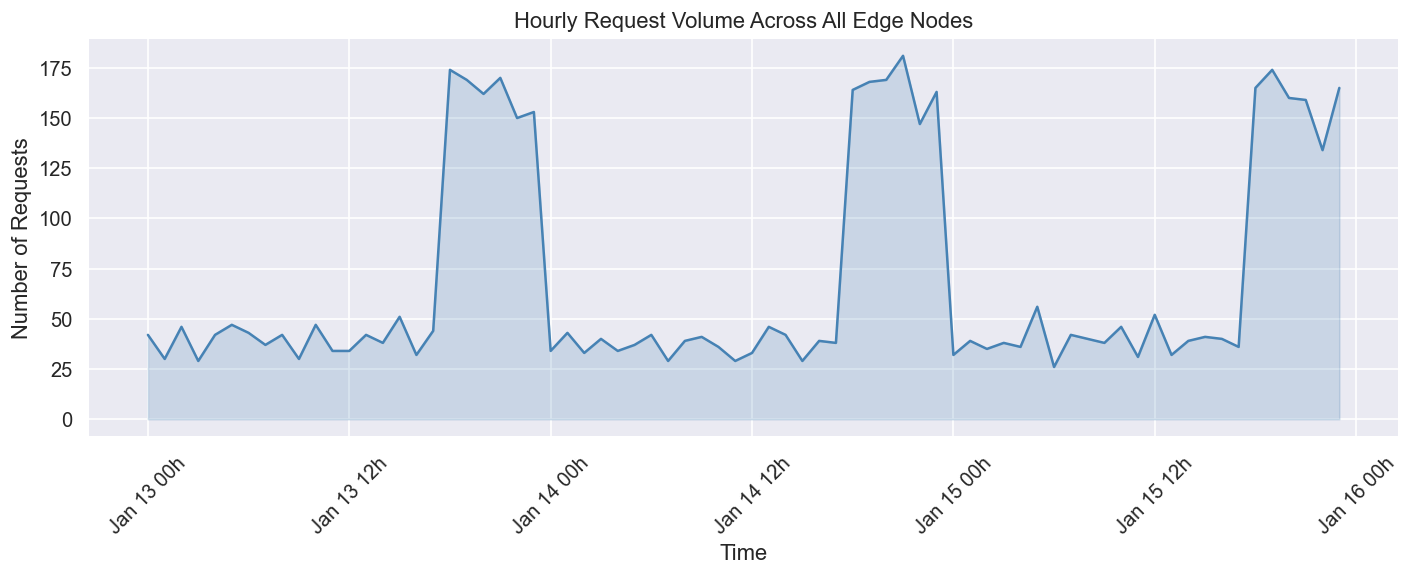

In [6]:
##hourly req volume plot
hourly = df.groupby(df['timestamp'].dt.floor('h')).size().reset_index(name='requests')

fig, ax = plt.subplots()
ax.plot(hourly['timestamp'], hourly['requests'], linewidth=1.5, color='steelblue')
ax.fill_between(hourly['timestamp'], hourly['requests'], alpha=0.2, color='steelblue')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d %Hh'))
plt.xticks(rotation=45)
ax.set_title('Hourly Request Volume Across All Edge Nodes')
ax.set_xlabel('Time')
ax.set_ylabel('Number of Requests')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_hourly_requests.png', dpi=150)
plt.show()

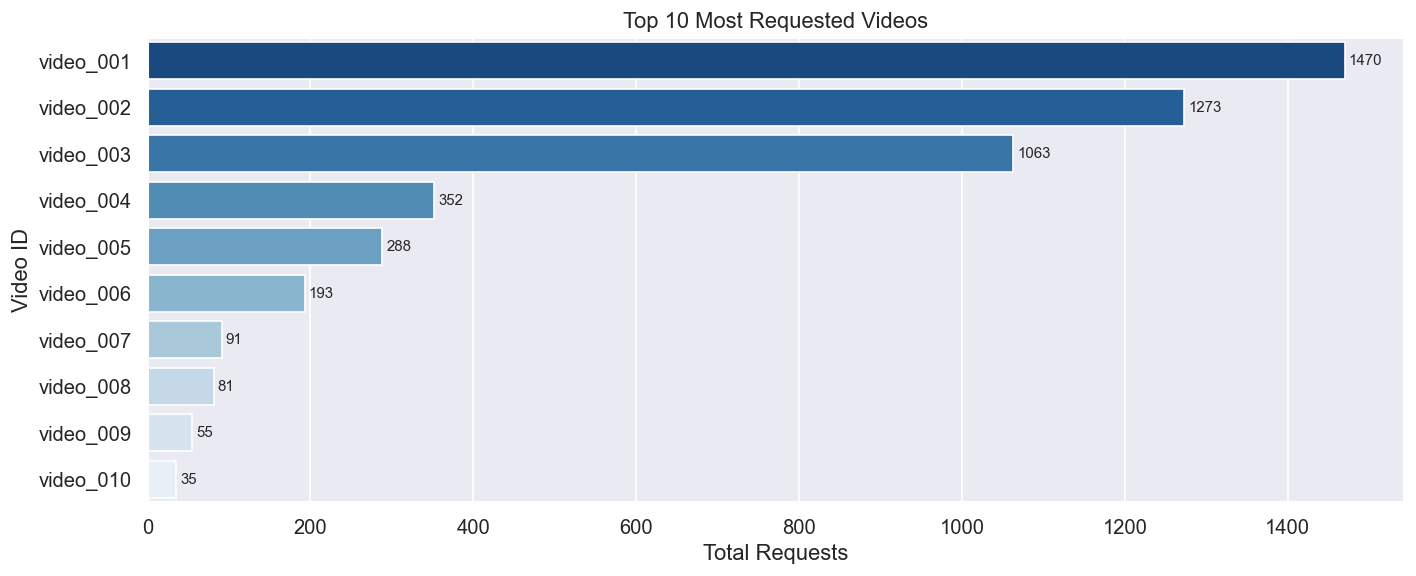

In [7]:
#top 10 most requested video
top_videos = df['video_id'].value_counts().head(10)

fig, ax = plt.subplots()
sns.barplot(x=top_videos.values, y=top_videos.index, palette='Blues_r', ax=ax)
ax.set_title('Top 10 Most Requested Videos')
ax.set_xlabel('Total Requests')
ax.set_ylabel('Video ID')

for i, v in enumerate(top_videos.values):
    ax.text(v + 5, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_top_videos.png', dpi=150)
plt.show()

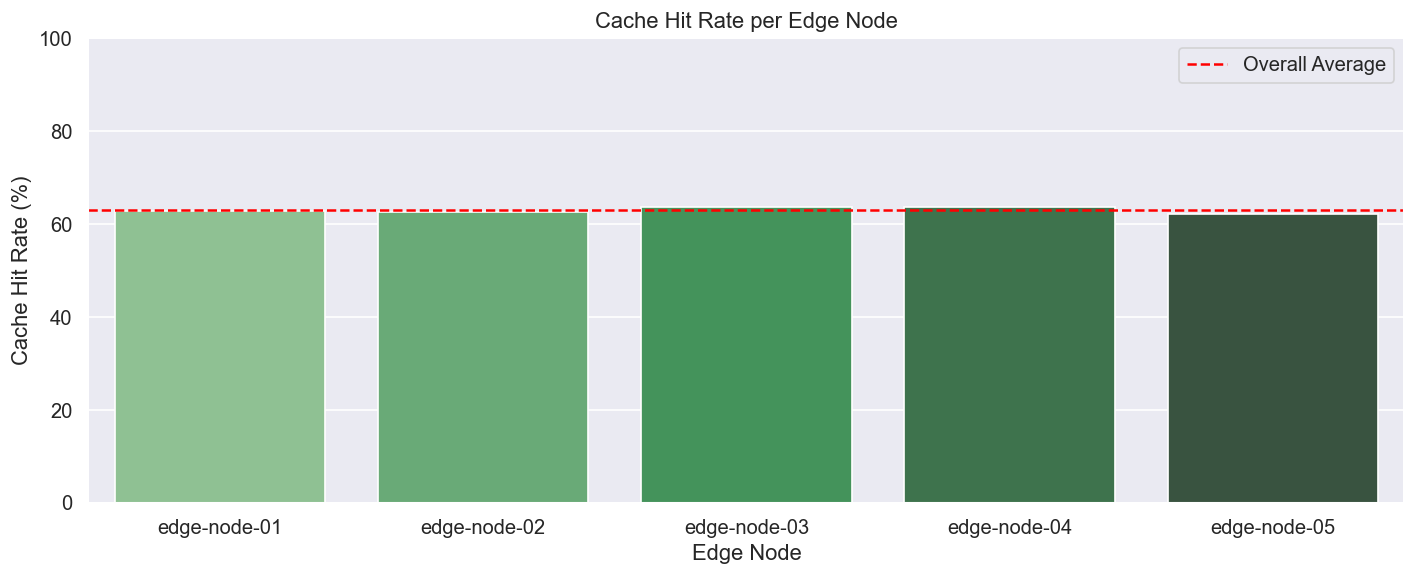

Overall cache hit rate: 62.9%


In [8]:
#cache hit rate per edge node
cache_by_node = df.groupby('edge_node_id')['cache_hit'].mean().reset_index()
cache_by_node['cache_hit_pct'] = cache_by_node['cache_hit'] * 100

fig, ax = plt.subplots()
sns.barplot(data=cache_by_node, x='edge_node_id', y='cache_hit_pct', palette='Greens_d', ax=ax)
ax.set_title('Cache Hit Rate per Edge Node')
ax.set_xlabel('Edge Node')
ax.set_ylabel('Cache Hit Rate (%)')
ax.set_ylim(0, 100)
ax.axhline(cache_by_node['cache_hit_pct'].mean(), color='red', linestyle='--', label='Overall Average')
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_cache_hit_per_node.png', dpi=150)
plt.show()
print(f"Overall cache hit rate: {cache_by_node['cache_hit_pct'].mean():.1f}%")

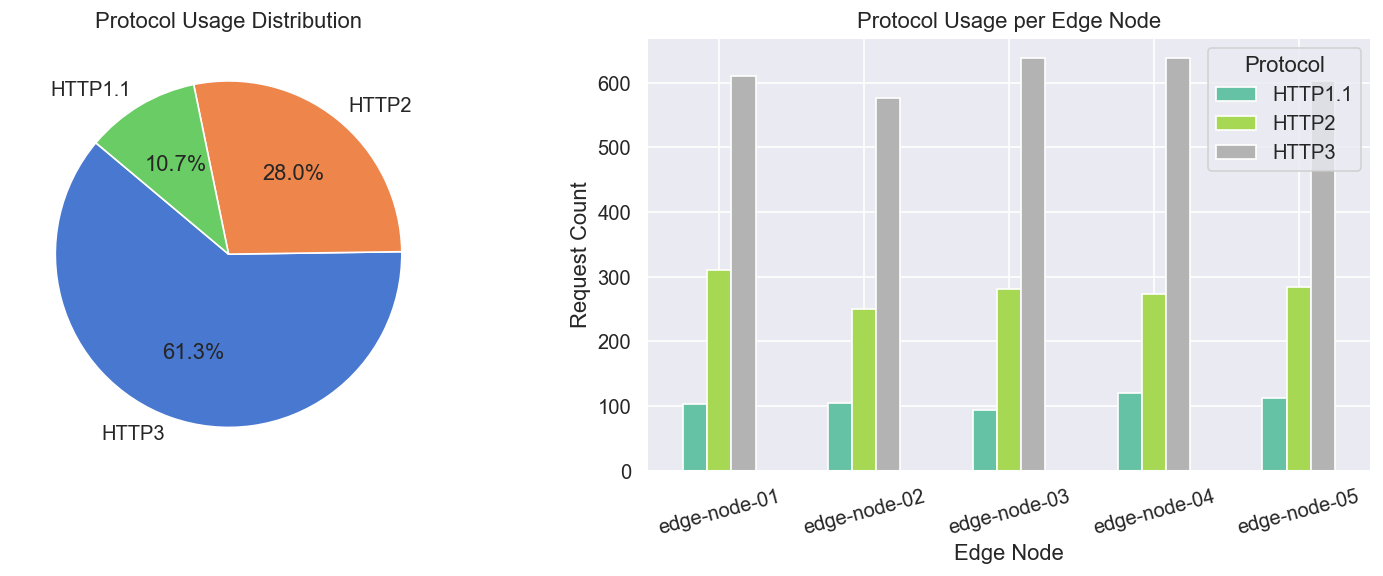

In [10]:
#Protocol Usage Breakdown
protocol_counts = df['protocol'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
ax1.pie(protocol_counts.values, labels=protocol_counts.index,
        autopct='%1.1f%%', colors=sns.color_palette('muted'),
        startangle=140, wedgeprops=dict(edgecolor='white'))
ax1.set_title('Protocol Usage Distribution')

# Bar chart by edge node
protocol_by_node = df.groupby(['edge_node_id', 'protocol']).size().unstack(fill_value=0)
protocol_by_node.plot(kind='bar', ax=ax2, colormap='Set2', edgecolor='white')
ax2.set_title('Protocol Usage per Edge Node')
ax2.set_xlabel('Edge Node')
ax2.set_ylabel('Request Count')
ax2.tick_params(axis='x', rotation=15)
ax2.legend(title='Protocol')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_protocols.png', dpi=150)
plt.show()

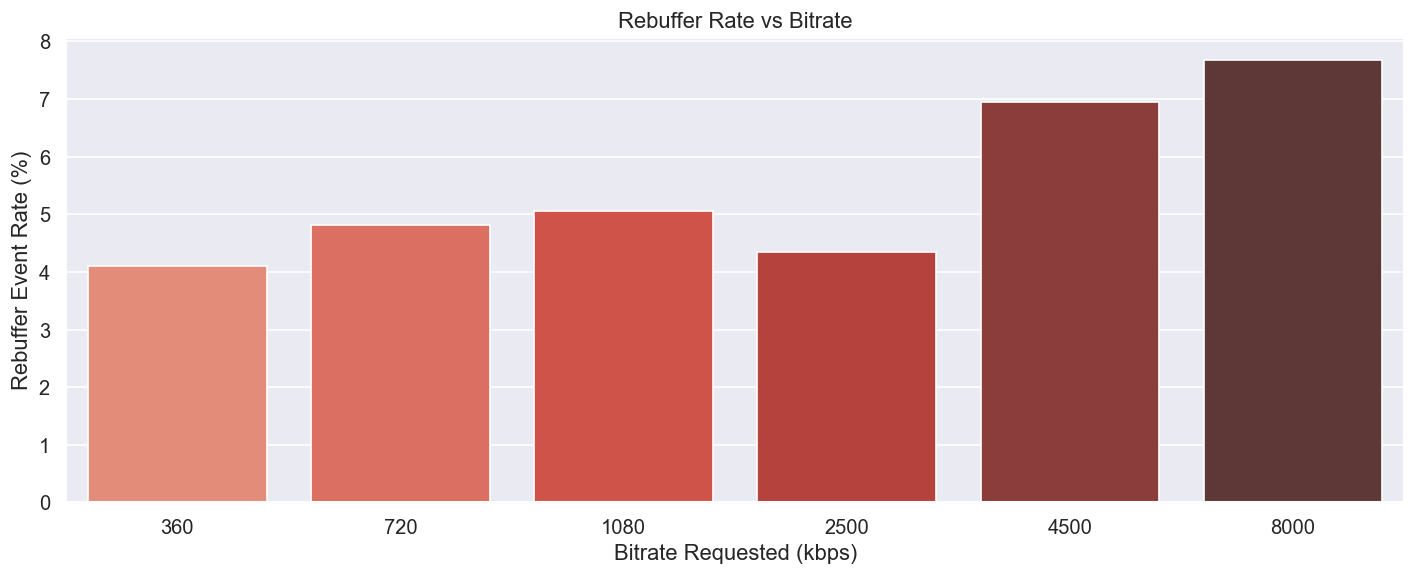

In [13]:
#Rebuffer Rate vs Bitrate
rebuffer_by_bitrate = df.groupby('bitrate_requested_kbps')['rebuffer_event'].mean().reset_index()
rebuffer_by_bitrate['rebuffer_pct'] = rebuffer_by_bitrate['rebuffer_event'] * 100

fig, ax = plt.subplots()
sns.barplot(data=rebuffer_by_bitrate, x='bitrate_requested_kbps', y='rebuffer_pct',
            palette='Reds_d', ax=ax)
ax.set_title('Rebuffer Rate vs Bitrate')
ax.set_xlabel('Bitrate Requested (kbps)')
ax.set_ylabel('Rebuffer Event Rate (%)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_rebuffer_vs_bitrate.png', dpi=150)
plt.show()

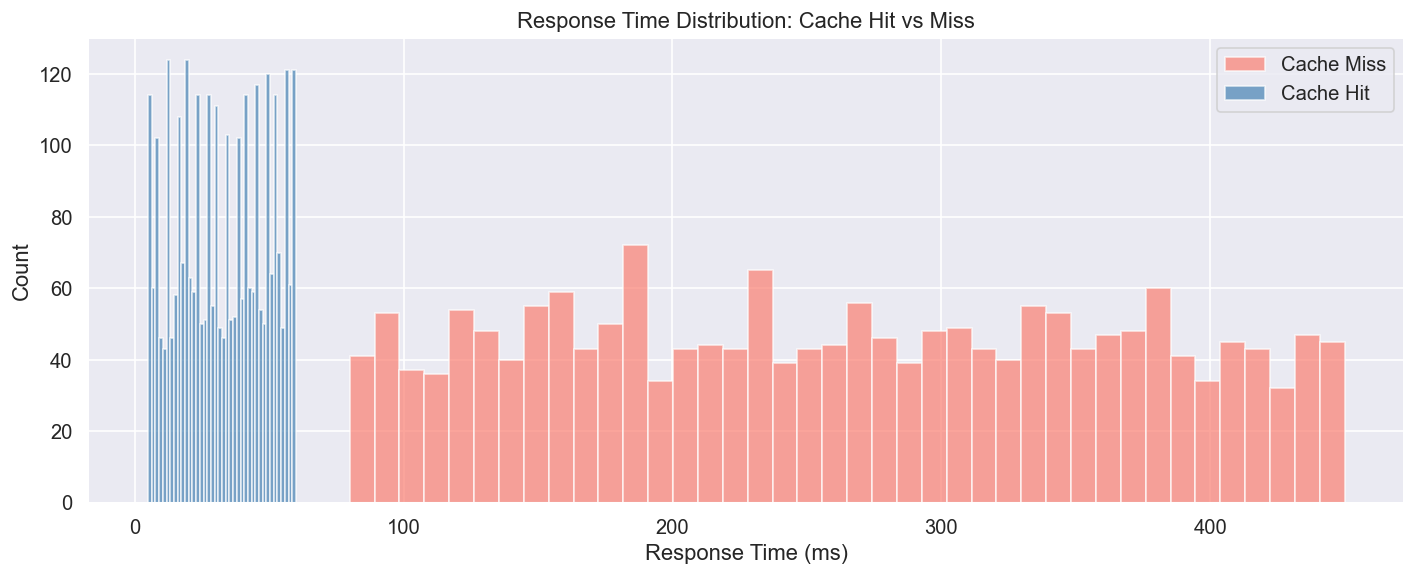

            count   mean    std   min    25%    50%    75%    max
cache_hit                                                        
False      1857.0  262.3  105.2  80.0  172.0  262.0  353.0  450.0
True       3143.0   32.9   16.3   5.0   19.0   33.0   47.0   60.0


In [15]:
#Cache Hit vs Miss
fig, ax = plt.subplots()

miss = df[df['cache_hit'] == False]['response_time_ms']
hit = df[df['cache_hit'] == True]['response_time_ms']

ax.hist(miss, bins=40, alpha=0.7, color='salmon', label='Cache Miss')
ax.hist(hit, bins=40, alpha=0.7, color='steelblue', label='Cache Hit')

ax.set_title('Response Time Distribution: Cache Hit vs Miss')
ax.set_xlabel('Response Time (ms)')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_response_time_dist.png', dpi=150)
plt.show()

print(df.groupby('cache_hit')['response_time_ms']
      .describe()
      .round(1))

In [16]:
print("  EDA SUMMARY")
print("═" * 50)
print(f"  Total requests      : {len(df):,}")
print(f"  Time span           : {(df['timestamp'].max() - df['timestamp'].min())}")
print(f"  Unique videos       : {df['video_id'].nunique()}")
print(f"  Unique users        : {df['client_id'].nunique()}")
print(f"  Unique edge nodes   : {df['edge_node_id'].nunique()}")
print(f"  Overall cache hit % : {df['cache_hit'].mean()*100:.1f}%")
print(f"  Overall rebuffer %  : {df['rebuffer_event'].mean()*100:.1f}%")
print(f"  Avg response (hit)  : {df[df['cache_hit']==True]['response_time_ms'].mean():.1f} ms")
print(f"  Avg response (miss) : {df[df['cache_hit']==False]['response_time_ms'].mean():.1f} ms")
print(f"  Error rate (non-200): {(df['status_code'] != 200).mean()*100:.1f}%")

  EDA SUMMARY
══════════════════════════════════════════════════
  Total requests      : 5,000
  Time span           : 2 days 23:58:41.410000
  Unique videos       : 20
  Unique users        : 500
  Unique edge nodes   : 5
  Overall cache hit % : 62.9%
  Overall rebuffer %  : 5.5%
  Avg response (hit)  : 32.9 ms
  Avg response (miss) : 262.3 ms
  Error rate (non-200): 2.0%


In [17]:
#Initialize Ray
if ray.is_initialized():
    ray.shutdown()

ray.init(ignore_reinit_error=True)

print(f"   CPUs available : {ray.cluster_resources()['CPU']:.0f}")
print(f"   Dashboard      : http://127.0.0.1:8265")

2026-02-22 01:52:10,414	INFO worker.py:2013 -- Started a local Ray instance.


   CPUs available : 16
   Dashboard      : http://127.0.0.1:8265


In [22]:
os.environ["PYTHONIOENCODING"] = "utf-8"

import logging
logging.getLogger("ray.data").setLevel(logging.ERROR)

In [23]:
#Benchmark: Pandas vs Ray Data

#Pandas
start = time.time()
df_pandas = pd.read_json(DATA_PATH, lines=True)
pandas_load_time = time.time() - start
print(f"Pandas load time : {pandas_load_time:.3f}s")

# Ray Data
start = time.time()
ds = rd.read_json(DATA_PATH, file_extensions=["ndjson"])
ray_load_time = time.time() - start
print(f"Ray Data load time : {ray_load_time:.3f}s")

print(f"\nRay dataset schema:\n{ds.schema()}")
print(f"Total rows: {ds.count():,}")

Pandas load time : 0.061s
Ray Data load time : 0.009s

Ray dataset schema:
Column                  Type
------                  ----
log_version             string
timestamp               string
edge_node_id            string
client_id               string
session_id              string
video_id                string
video_category          string
segment_number          int64
request_type            string
cache_hit               bool
response_time_ms        int64
bytes_sent              int64
client_region           string
protocol                string
bitrate_requested_kbps  int64
rebuffer_event          bool
status_code             int64
Total rows: 5,000


In [25]:
# Aggregation 1: Views per (video_id, hour) with Ray
start = time.time()

df_ray = df_pandas.copy()  
df_ray['timestamp']   = pd.to_datetime(df_ray['timestamp'])
df_ray['hour_window'] = df_ray['timestamp'].dt.floor('h')

views_per_video_hour = (
    df_ray
    .groupby(['video_id', 'hour_window'])
    .agg(
        total_requests  = ('video_id',              'count'),
        cache_hit_rate  = ('cache_hit',             'mean'),
        avg_response_ms = ('response_time_ms',      'mean'),
        rebuffer_rate   = ('rebuffer_event',        'mean'),
        avg_bitrate     = ('bitrate_requested_kbps','mean'),
    )
    .reset_index()
    .sort_values(['video_id', 'hour_window'])
)

ray_agg_time = time.time() - start
print(f"Aggregation complete in {ray_agg_time:.3f}s")
print(f"   Shape: {views_per_video_hour.shape}")
views_per_video_hour.head(8)

Aggregation complete in 0.021s
   Shape: (643, 7)


,video_id,hour_window,total_requests,cache_hit_rate,avg_response_ms,rebuffer_rate,avg_bitrate
0,video_001,2025-01-13 00:00:00+00:00,12,0.416667,149.666667,0.083333,3876.666667
1,video_001,2025-01-13 01:00:00+00:00,7,0.571429,126.285714,0.000000,3360.000000
2,video_001,2025-01-13 02:00:00+00:00,15,0.533333,142.800000,0.066667,3317.333333
3,video_001,2025-01-13 03:00:00+00:00,11,0.727273,94.909091,0.000000,3229.090909
4,video_001,2025-01-13 04:00:00+00:00,17,0.705882,95.941176,0.058824,2612.941176
5,video_001,2025-01-13 05:00:00+00:00,15,0.733333,83.066667,0.000000,1766.666667
6,video_001,2025-01-13 06:00:00+00:00,14,0.714286,103.714286,0.071429,2967.142857
7,video_001,2025-01-13 07:00:00+00:00,10,0.300000,189.900000,0.100000,1582.000000


In [26]:
#Aggregation 2: Cache Hit Rate per (edge_node, video)
cache_by_node_video = (
    df_ray
    .groupby(['edge_node_id', 'video_id'])
    .agg(
        total_requests = ('video_id',   'count'),
        cache_hit_rate = ('cache_hit',  'mean'),
        avg_response   = ('response_time_ms', 'mean'),
    )
    .reset_index()
    .sort_values('cache_hit_rate', ascending=False)
)

print(f"Cache hit by node & video — shape: {cache_by_node_video.shape}")
cache_by_node_video.head(8)

Cache hit by node & video — shape: (95, 5)


,edge_node_id,video_id,total_requests,cache_hit_rate,avg_response
29,edge-node-02,video_012,1,1.000000,25.000000
68,edge-node-04,video_013,2,1.000000,17.500000
54,edge-node-03,video_019,1,1.000000,12.000000
91,edge-node-05,video_017,1,1.000000,15.000000
38,edge-node-03,video_003,235,0.872340,55.812766
58,edge-node-04,video_003,208,0.860577,64.408654
21,edge-node-02,video_003,208,0.846154,70.908654
2,edge-node-01,video_003,211,0.824645,72.568720


In [27]:
#Aggregation 3: Average Response Time per Edge Node
response_by_node = (
    df_ray
    .groupby('edge_node_id')
    .agg(
        total_requests  = ('video_id',         'count'),
        avg_response_ms = ('response_time_ms', 'mean'),
        p95_response_ms = ('response_time_ms', lambda x: x.quantile(0.95)),
        cache_hit_rate  = ('cache_hit',        'mean'),
        error_rate      = ('status_code',      lambda x: (x != 200).mean()),
    )
    .reset_index()
    .round(2)
)

print("Response time per edge node:")
print(response_by_node.to_string(index=False))

Response time per edge node:
edge_node_id  total_requests  avg_response_ms  p95_response_ms  cache_hit_rate  error_rate
edge-node-01            1025           117.45           383.60            0.63        0.02
edge-node-02             931           124.78           410.00            0.63        0.02
edge-node-03            1013           114.27           386.00            0.63        0.02
edge-node-04            1032           115.91           387.45            0.63        0.02
edge-node-05             999           118.70           397.10            0.62        0.02


In [28]:
parquet_path = OUTPUT_DIR / 'views_per_video_hour.parquet'
views_per_video_hour.to_parquet(parquet_path, index=False)

original_size = Path(DATA_PATH).stat().st_size / 1024
parquet_size  = parquet_path.stat().st_size / 1024

print(f"   Original NDJSON : {original_size:.1f} KB")
print(f"   Parquet file    : {parquet_size:.1f} KB")
print(f"   Size reduction  : {(1 - parquet_size/original_size)*100:.1f}%")

   Original NDJSON : 2222.5 KB
   Parquet file    : 14.2 KB
   Size reduction  : 99.4%


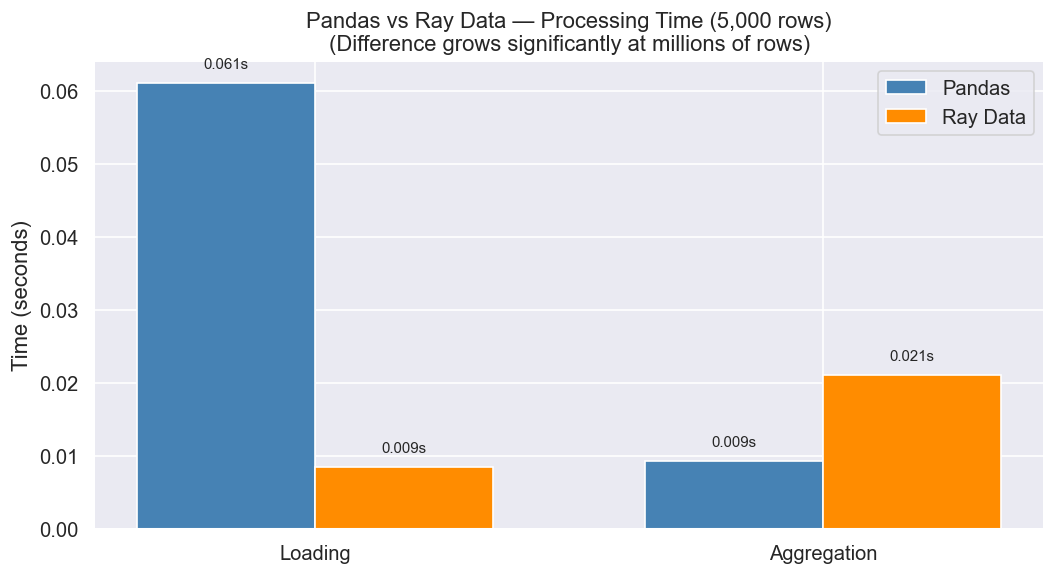

In [29]:
tasks   = ['Data Loading', 'Aggregation']
pandas_times = [pandas_load_time, None]   # we'll do pandas agg below

# Pandas aggregation time
start = time.time()
_ = (
    df_pandas.assign(hour_window=pd.to_datetime(df_pandas['timestamp']).dt.floor('h'))
    .groupby(['video_id', 'hour_window'])
    .agg(total_requests=('video_id','count'), cache_hit_rate=('cache_hit','mean'))
    .reset_index()
)
pandas_agg_time = time.time() - start

labels       = ['Loading', 'Aggregation']
pandas_times = [pandas_load_time, pandas_agg_time]
ray_times    = [ray_load_time,    ray_agg_time]

x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - w/2, pandas_times, w, label='Pandas',   color='steelblue',  edgecolor='white')
bars2 = ax.bar(x + w/2, ray_times,    w, label='Ray Data', color='darkorange', edgecolor='white')

ax.set_title('Pandas vs Ray Data — Processing Time (5,000 rows)\n'
             '(Difference grows significantly at millions of rows)')
ax.set_ylabel('Time (seconds)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}s', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}s', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_ray_vs_pandas.png', dpi=150)
plt.show()

In [36]:
print("Big Data Processing")
print("═" * 55)
print(f"  Ray workers (CPUs)       : {ray.cluster_resources()['CPU']:.0f}")
print(f"  Pandas load time         : {pandas_load_time:.3f}s")
print(f"  Ray load time            : {ray_load_time:.3f}s")
print(f"  Pandas aggregation time  : {pandas_agg_time:.3f}s")
print(f"  Ray aggregation time     : {ray_agg_time:.3f}s")
print(f"  Aggregated rows output   : {views_per_video_hour.shape[0]:,}")
print(f"  Parquet saved to         : {parquet_path}")

Big Data Processing
═══════════════════════════════════════════════════════
  Ray workers (CPUs)       : 16
  Pandas load time         : 0.061s
  Ray load time            : 0.009s
  Pandas aggregation time  : 0.009s
  Ray aggregation time     : 0.021s
  Aggregated rows output   : 643
  Parquet saved to         : D:\1-Oulu-Courses\Distributed-System\Data\outputs\views_per_video_hour.parquet


In [31]:
feat = views_per_video_hour.copy()

#Time features
feat['hour_of_day']  = feat['hour_window'].dt.hour
feat['day_of_week']  = feat['hour_window'].dt.dayofweek   # 0=Monday
feat['is_weekend']   = feat['day_of_week'].isin([5, 6]).astype(int)
feat['is_peak_hour'] = feat['hour_of_day'].isin(range(18, 24)).astype(int)

feat[['video_id','hour_window','hour_of_day','day_of_week','is_weekend','is_peak_hour']].head(5)

,video_id,hour_window,hour_of_day,day_of_week,is_weekend,is_peak_hour
0,video_001,2025-01-13 00:00:00+00:00,0,0,0,0
1,video_001,2025-01-13 01:00:00+00:00,1,0,0,0
2,video_001,2025-01-13 02:00:00+00:00,2,0,0,0
3,video_001,2025-01-13 03:00:00+00:00,3,0,0,0
4,video_001,2025-01-13 04:00:00+00:00,4,0,0,0


In [32]:
#Rolling Window Features
feat = feat.sort_values(['video_id', 'hour_window']).reset_index(drop=True)

# Rolling windows per video (1h, 3h, 6h lookback)
feat['views_last_1h'] = (
    feat.groupby('video_id')['total_requests']
    .shift(1)                        # lag by 1 so we don't leak future data
    .fillna(0)
)

feat['views_last_3h'] = (
    feat.groupby('video_id')['total_requests']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    .fillna(0)
)

feat['views_last_6h'] = (
    feat.groupby('video_id')['total_requests']
    .transform(lambda x: x.shift(1).rolling(6, min_periods=1).mean())
    .fillna(0)
)

feat['trending_score'] = (
    feat['views_last_1h'] / (feat['views_last_6h'] + 1e-6)
).round(4)

feat[['video_id','hour_window','total_requests',
      'views_last_1h','views_last_3h','views_last_6h','trending_score']].head(8)

,video_id,hour_window,total_requests,views_last_1h,views_last_3h,views_last_6h,trending_score
0,video_001,2025-01-13 00:00:00+00:00,12,0.0,0.000000,0.000000,0.0000
1,video_001,2025-01-13 01:00:00+00:00,7,12.0,12.000000,12.000000,1.0000
2,video_001,2025-01-13 02:00:00+00:00,15,7.0,9.500000,9.500000,0.7368
3,video_001,2025-01-13 03:00:00+00:00,11,15.0,11.333333,11.333333,1.3235
4,video_001,2025-01-13 04:00:00+00:00,17,11.0,11.000000,11.250000,0.9778
5,video_001,2025-01-13 05:00:00+00:00,15,17.0,14.333333,12.400000,1.3710
6,video_001,2025-01-13 06:00:00+00:00,14,15.0,14.333333,12.833333,1.1688
7,video_001,2025-01-13 07:00:00+00:00,10,14.0,15.333333,13.166667,1.0633


In [33]:
# Target label
# Compute each video's average hourly requests
video_avg = feat.groupby('video_id')['total_requests'].transform('mean')

# Next hour's requests (shift -1 = look one step ahead)
feat['next_hour_requests'] = feat.groupby('video_id')['total_requests'].shift(-1)

# Spike = next hour is more than 2x the video's average
feat['is_spike'] = (feat['next_hour_requests'] > 2 * video_avg).astype(int)

feat = feat.dropna(subset=['next_hour_requests']).reset_index(drop=True)

spike_rate = feat['is_spike'].mean() * 100
print(f"   Total samples : {len(feat):,}")
print(f"   Spike rate    : {spike_rate:.1f}%  ({feat['is_spike'].sum()} spikes out of {len(feat)})")
print(f"   Class balance : {feat['is_spike'].value_counts().to_dict()}")

   Total samples : 623
   Spike rate    : 13.2%  (82 spikes out of 623)
   Class balance : {0: 541, 1: 82}


In [34]:
#Final Feature Matrix & Train/Test Split
FEATURE_COLS = [
    'hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour',
    'views_last_1h', 'views_last_3h', 'views_last_6h', 'trending_score',
    'cache_hit_rate', 'avg_response_ms', 'rebuffer_rate', 'avg_bitrate',
    'total_requests',
]
TARGET_COL = 'is_spike'

split_idx  = int(len(feat) * 0.8)
train_df   = feat.iloc[:split_idx]
test_df    = feat.iloc[split_idx:]

X_train = train_df[FEATURE_COLS].values
y_train = train_df[TARGET_COL].values
X_test  = test_df[FEATURE_COLS].values
y_test  = test_df[TARGET_COL].values

print(f"   Train: {X_train.shape}  |  Spikes: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"   Test : {X_test.shape}   |  Spikes: {y_test.sum()} ({y_test.mean()*100:.1f}%)")

   Train: (498, 13)  |  Spikes: 79 (15.9%)
   Test : (125, 13)   |  Spikes: 3 (2.4%)


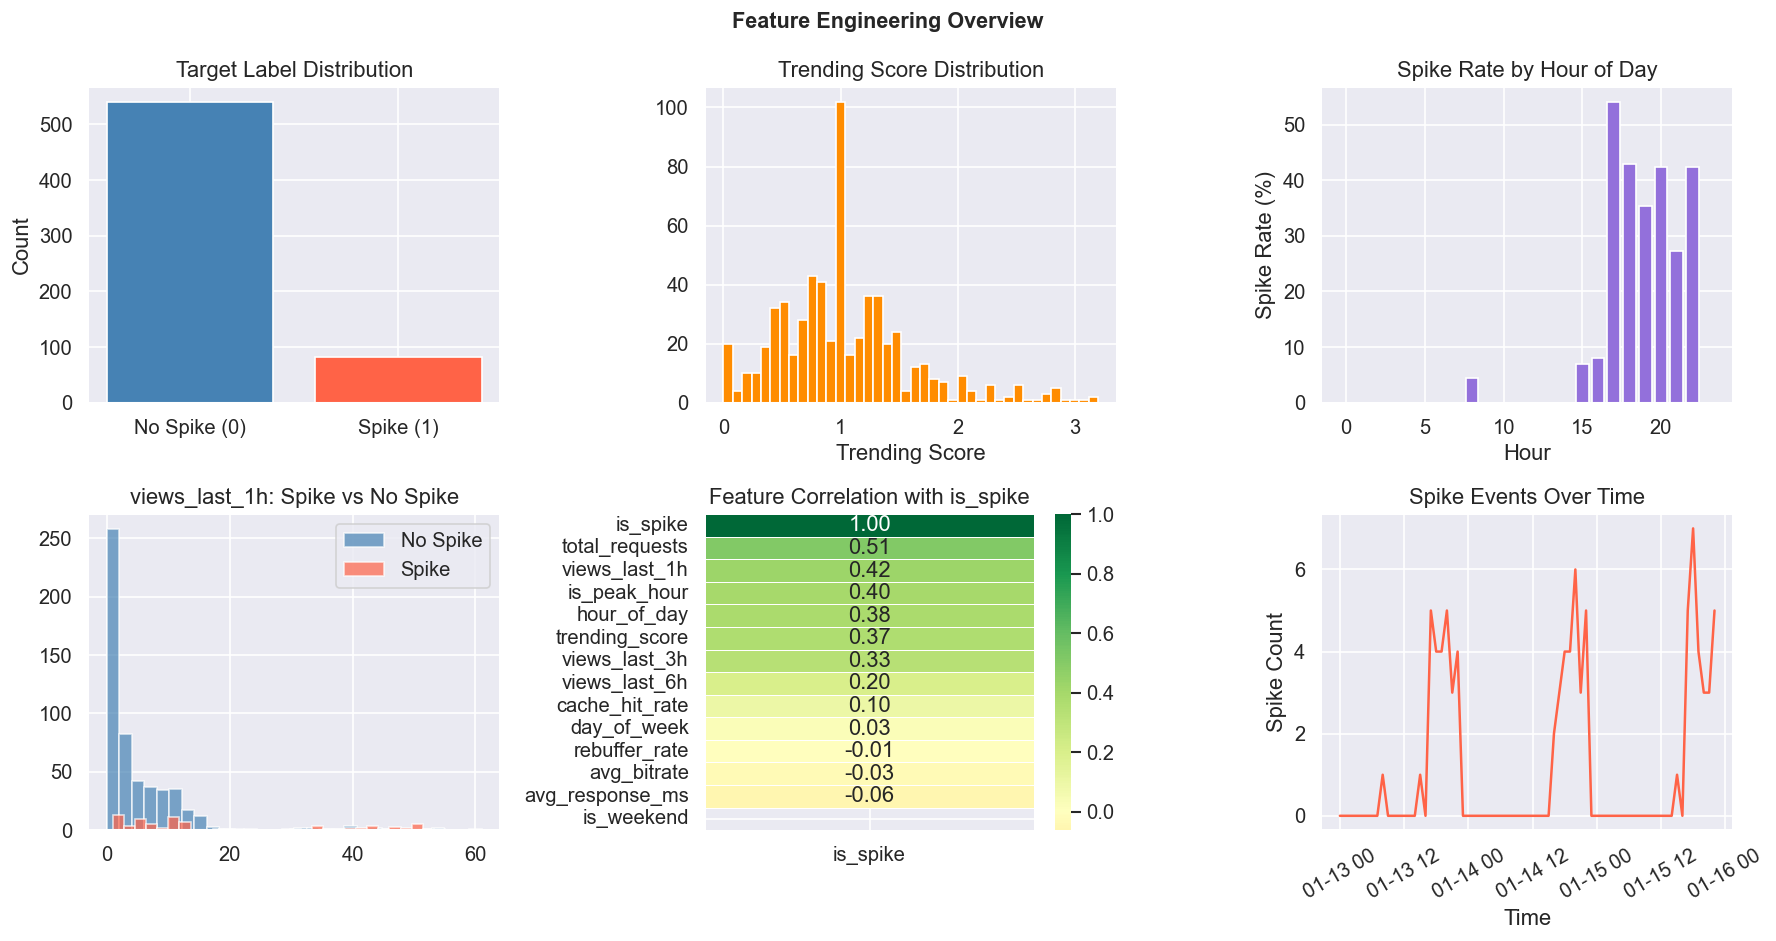

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

#Spike distribution
axes[0,0].bar(['No Spike (0)', 'Spike (1)'],
              feat['is_spike'].value_counts().sort_index().values,
              color=['steelblue', 'tomato'], edgecolor='white')
axes[0,0].set_title('Target Label Distribution')
axes[0,0].set_ylabel('Count')

#Trending score distribution
axes[0,1].hist(feat['trending_score'].clip(0, 5), bins=40, color='darkorange', edgecolor='white')
axes[0,1].set_title('Trending Score Distribution')
axes[0,1].set_xlabel('Trending Score')

#Spikes by hour of day
spike_by_hour = feat.groupby('hour_of_day')['is_spike'].mean() * 100
axes[0,2].bar(spike_by_hour.index, spike_by_hour.values, color='mediumpurple', edgecolor='white')
axes[0,2].set_title('Spike Rate by Hour of Day')
axes[0,2].set_xlabel('Hour')
axes[0,2].set_ylabel('Spike Rate (%)')

#views_last_1h for spike vs non-spike
feat[feat['is_spike']==0]['views_last_1h'].hist(ax=axes[1,0], bins=30, alpha=0.7,
    color='steelblue', label='No Spike')
feat[feat['is_spike']==1]['views_last_1h'].hist(ax=axes[1,0], bins=30, alpha=0.7,
    color='tomato', label='Spike')
axes[1,0].set_title('views_last_1h: Spike vs No Spike')
axes[1,0].legend()

#Correlation heatmap of features
corr = feat[FEATURE_COLS + [TARGET_COL]].corr()
sns.heatmap(corr[[TARGET_COL]].sort_values(TARGET_COL, ascending=False),
            ax=axes[1,1], annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5)
axes[1,1].set_title('Feature Correlation with is_spike')

#pikes over time
spikes_over_time = feat.groupby('hour_window')['is_spike'].sum().reset_index()
axes[1,2].plot(spikes_over_time['hour_window'], spikes_over_time['is_spike'],
               color='tomato', linewidth=1.5)
axes[1,2].set_title('Spike Events Over Time')
axes[1,2].set_xlabel('Time')
axes[1,2].set_ylabel('Spike Count')
axes[1,2].tick_params(axis='x', rotation=30)

plt.suptitle('Feature Engineering Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_feature_engineering.png', dpi=150)
plt.show()

In [37]:
print("Feature Engineering")
print("═" * 55)
print(f"  Total samples     : {len(feat):,}")
print(f"  Feature columns   : {len(FEATURE_COLS)}")
print(f"  Spike rate        : {feat['is_spike'].mean()*100:.1f}%")
print(f"  Train set size    : {X_train.shape[0]:,}")
print(f"  Test set size     : {X_test.shape[0]:,}")
print(f"\n  Features used:")
for f in FEATURE_COLS:
    print(f"    - {f}")

Feature Engineering
═══════════════════════════════════════════════════════
  Total samples     : 623
  Feature columns   : 13
  Spike rate        : 13.2%
  Train set size    : 498
  Test set size     : 125

  Features used:
    - hour_of_day
    - day_of_week
    - is_weekend
    - is_peak_hour
    - views_last_1h
    - views_last_3h
    - views_last_6h
    - trending_score
    - cache_hit_rate
    - avg_response_ms
    - rebuffer_rate
    - avg_bitrate
    - total_requests


In [38]:
# Scale Features + Handle Class Imbalance
from sklearn.preprocessing import StandardScaler

scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Class imbalance ratio
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"   Train class ratio  — 0: {neg}  1: {pos}")
print(f"   scale_pos_weight   : {scale_pos_weight:.2f}")

   Train class ratio  — 0: 419  1: 79
   scale_pos_weight   : 5.30


In [39]:
def evaluate_model(name, y_true, y_pred, y_prob=None):
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_prob) if y_prob is not None else float('nan')

    print(f"\n{'─'*45}")
    print(f"  Model : {name}")
    print(f"  Accuracy  : {acc*100:.1f}%")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  AUC-ROC   : {auc:.4f}")
    print(f"{'─'*45}")
    print(classification_report(y_true, y_pred, zero_division=0))

    return {'model': name, 'accuracy': acc, 'f1': f1, 'auc': auc}

In [40]:
# Model 1: Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_SEED)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

results_lr = evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr)


─────────────────────────────────────────────
  Model : Logistic Regression
  Accuracy  : 62.4%
  F1 Score  : 0.0408
  AUC-ROC   : 0.4809
─────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.97      0.63      0.77       122
           1       0.02      0.33      0.04         3

    accuracy                           0.62       125
   macro avg       0.50      0.48      0.40       125
weighted avg       0.95      0.62      0.75       125



In [41]:
#Model 2: XGBoost
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators     = 200,
    max_depth        = 4,
    learning_rate    = 0.05,
    scale_pos_weight = scale_pos_weight,   # handles class imbalance
    use_label_encoder= False,
    eval_metric      = 'logloss',
    random_state     = RANDOM_SEED,
)
xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

results_xgb = evaluate_model("XGBoost", y_test, y_pred_xgb, y_prob_xgb)


─────────────────────────────────────────────
  Model : XGBoost
  Accuracy  : 92.8%
  F1 Score  : 0.0000
  AUC-ROC   : 0.5191
─────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       122
           1       0.00      0.00      0.00         3

    accuracy                           0.93       125
   macro avg       0.49      0.48      0.48       125
weighted avg       0.95      0.93      0.94       125



In [42]:
#Model 3: LightGBM
import lightgbm as lgb

lgbm_model = lgb.LGBMClassifier(
    n_estimators    = 200,
    max_depth       = 4,
    learning_rate   = 0.05,
    class_weight    = 'balanced',
    random_state    = RANDOM_SEED,
    verbose         = -1,
)
lgbm_model.fit(X_train_scaled, y_train)

y_pred_lgbm = lgbm_model.predict(X_test_scaled)
y_prob_lgbm = lgbm_model.predict_proba(X_test_scaled)[:, 1]

results_lgbm = evaluate_model("LightGBM", y_test, y_pred_lgbm, y_prob_lgbm)


─────────────────────────────────────────────
  Model : LightGBM
  Accuracy  : 89.6%
  F1 Score  : 0.0000
  AUC-ROC   : 0.5423
─────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.97      0.92      0.95       122
           1       0.00      0.00      0.00         3

    accuracy                           0.90       125
   macro avg       0.49      0.46      0.47       125
weighted avg       0.95      0.90      0.92       125



In [43]:
#Model 4: LSTM
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).unsqueeze(1)
X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32).unsqueeze(1)
y_train_t = torch.tensor(y_train,        dtype=torch.float32)
y_test_t  = torch.tensor(y_test,         dtype=torch.float32)

#Weighted loss to handle class imbalance
pos_weight = torch.tensor([scale_pos_weight])

class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout)
        self.fc   = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(1)

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lstm_model = LSTMClassifier(input_size=len(FEATURE_COLS)).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
optimizer = optim.Adam(lstm_model.parameters(), lr=0.001)

EPOCHS     = 50
BATCH_SIZE = 32
dataset    = TensorDataset(X_train_t, y_train_t)
loader     = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

train_losses = []
lstm_model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(lstm_model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(loader))
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1}/{EPOCHS}  Loss: {train_losses[-1]:.4f}")

# Evaluate
lstm_model.eval()
with torch.no_grad():
    logits    = lstm_model(X_test_t.to(device))
    y_prob_lstm = torch.sigmoid(logits).cpu().numpy()
    y_pred_lstm = (y_prob_lstm > 0.5).astype(int)

results_lstm = evaluate_model("LSTM (PyTorch)", y_test, y_pred_lstm, y_prob_lstm)

  Epoch 10/50  Loss: 0.6157
  Epoch 20/50  Loss: 0.5082
  Epoch 30/50  Loss: 0.4614
  Epoch 40/50  Loss: 0.4339
  Epoch 50/50  Loss: 0.3887

─────────────────────────────────────────────
  Model : LSTM (PyTorch)
  Accuracy  : 72.0%
  F1 Score  : 0.0000
  AUC-ROC   : 0.4290
─────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.97      0.74      0.84       122
           1       0.00      0.00      0.00         3

    accuracy                           0.72       125
   macro avg       0.48      0.37      0.42       125
weighted avg       0.94      0.72      0.82       125



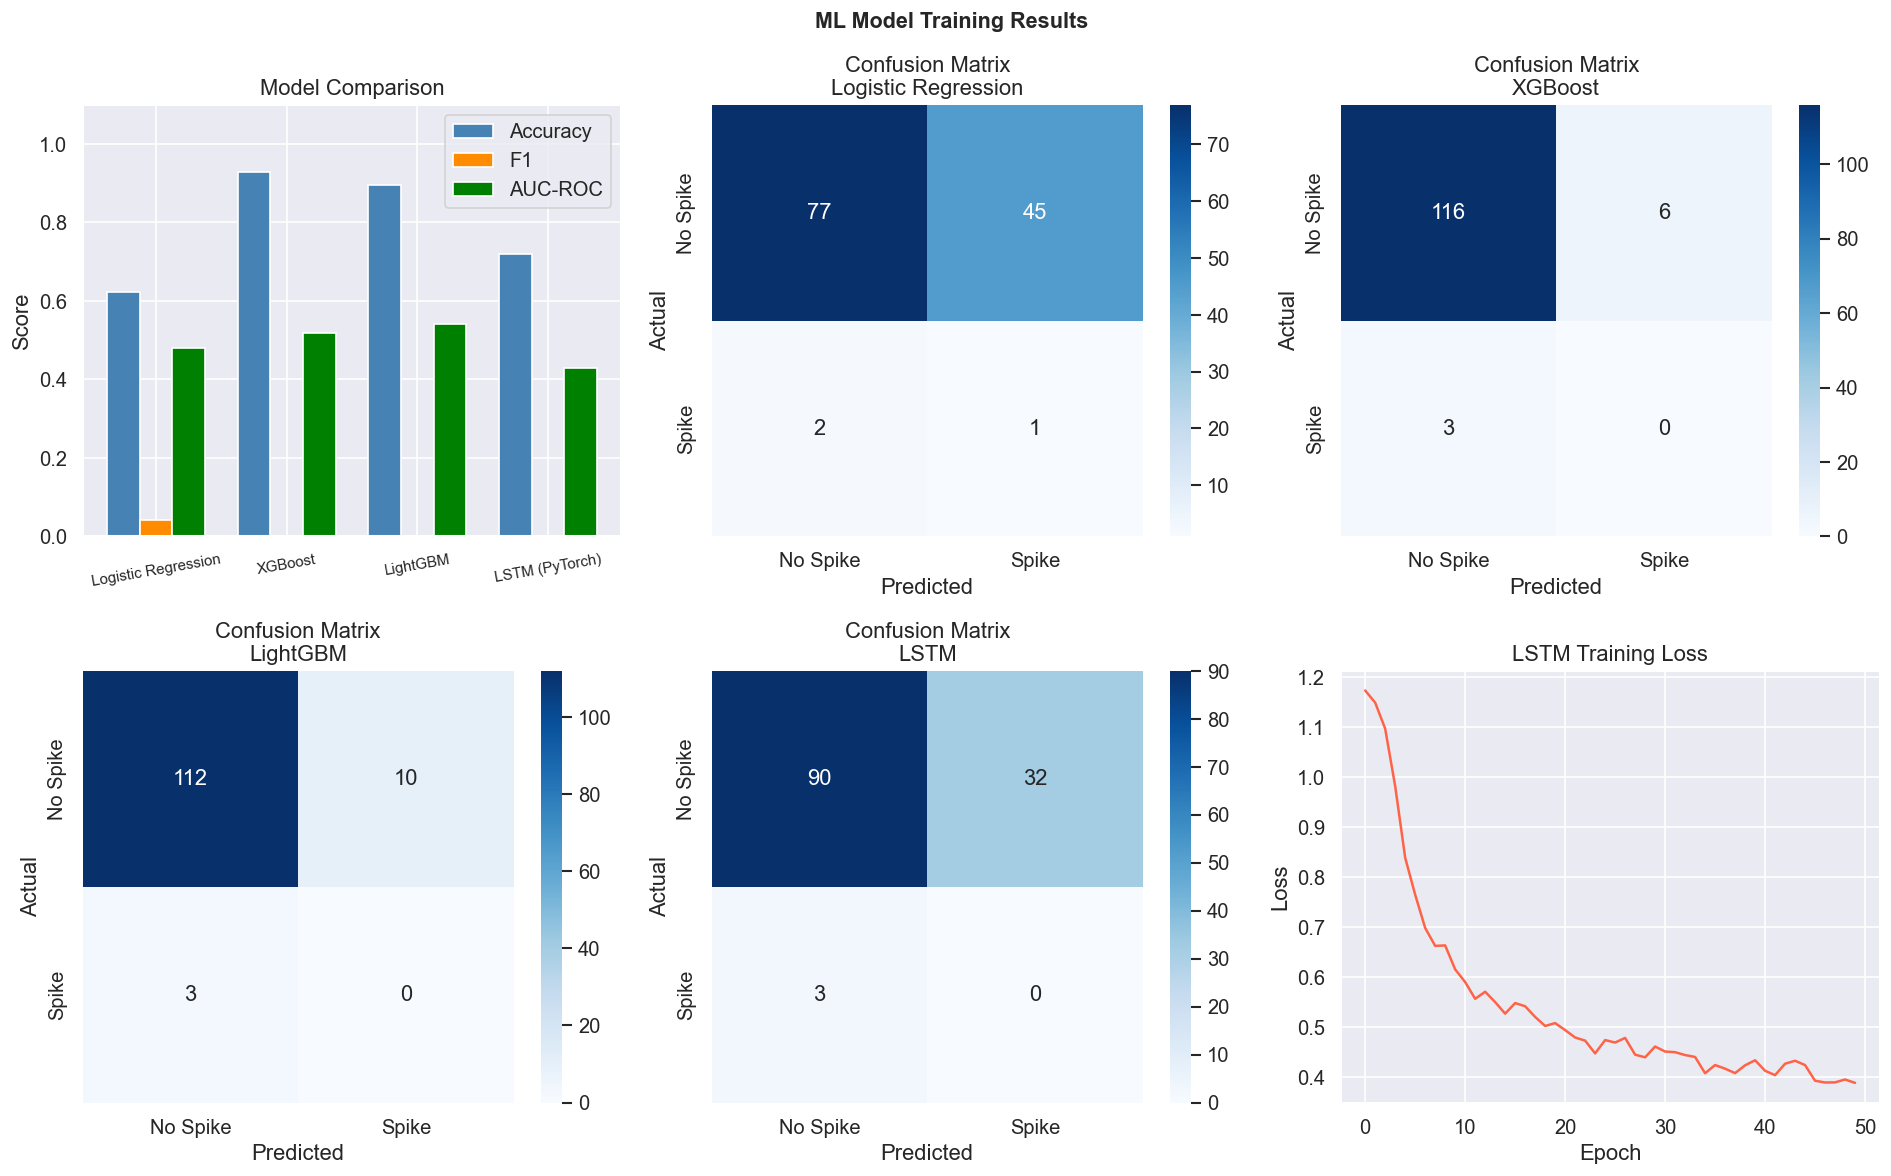

In [44]:
all_results = [results_lr, results_xgb, results_lgbm, results_lstm]
results_df  = pd.DataFrame(all_results).set_index('model')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Model comparison bar chart
x     = np.arange(len(results_df))
width = 0.25
axes[0,0].bar(x - width, results_df['accuracy'], width, label='Accuracy', color='steelblue')
axes[0,0].bar(x,         results_df['f1'],       width, label='F1',       color='darkorange')
axes[0,0].bar(x + width, results_df['auc'],      width, label='AUC-ROC',  color='green')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(results_df.index, rotation=10, fontsize=9)
axes[0,0].set_ylim(0, 1.1)
axes[0,0].set_title('Model Comparison')
axes[0,0].legend()
axes[0,0].set_ylabel('Score')

# Confusion matrix
models_cm = [
    ("Logistic Regression", y_pred_lr),
    ("XGBoost",             y_pred_xgb),
    ("LightGBM",            y_pred_lgbm),
    ("LSTM",                y_pred_lstm),
]
cm_axes = [axes[0,1], axes[0,2], axes[1,0], axes[1,1]]
for ax, (name, y_pred) in zip(cm_axes, models_cm):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Spike','Spike'],
                yticklabels=['No Spike','Spike'])
    ax.set_title(f'Confusion Matrix\n{name}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

# LSTM training loss curve
axes[1,2].plot(train_losses, color='tomato', linewidth=1.5)
axes[1,2].set_title('LSTM Training Loss')
axes[1,2].set_xlabel('Epoch')
axes[1,2].set_ylabel('Loss')

plt.suptitle(' ML Model Training Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_model_comparison.png', dpi=150)
plt.show()

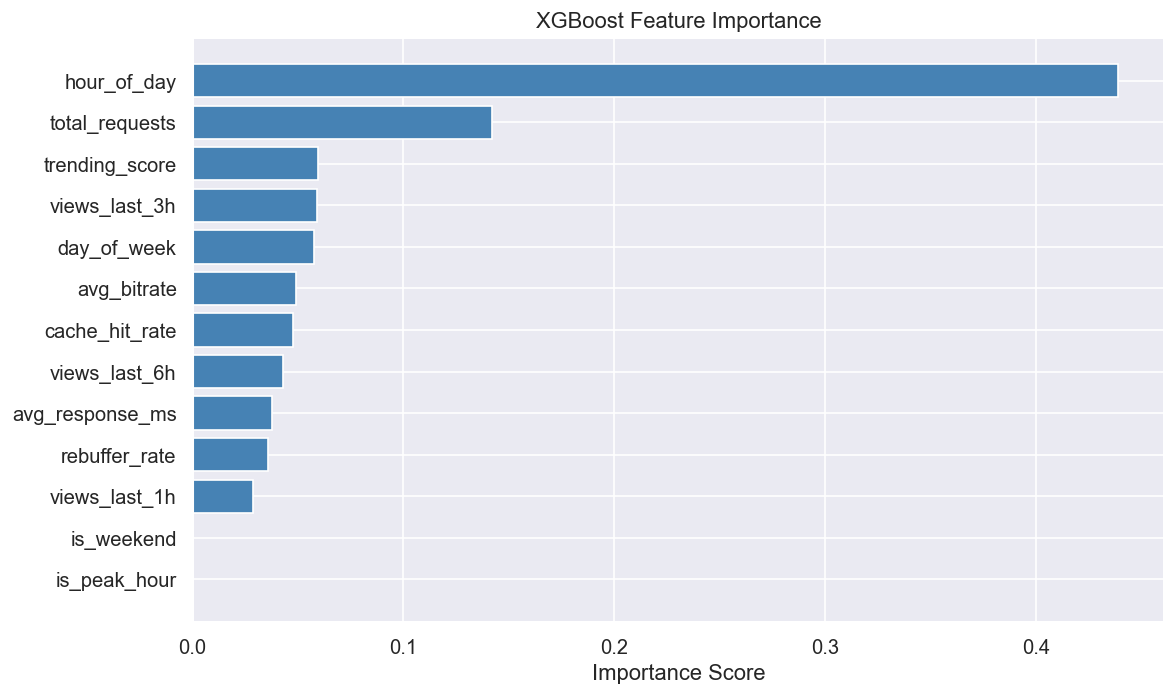

In [45]:
fig, ax = plt.subplots(figsize=(10, 6))
importance = xgb_model.feature_importances_
sorted_idx = np.argsort(importance)

ax.barh([FEATURE_COLS[i] for i in sorted_idx],
         importance[sorted_idx],
         color='steelblue', edgecolor='white')
ax.set_title('XGBoost Feature Importance')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_feature_importance.png', dpi=150)
plt.show()

In [46]:
print(" Model Training Results")
print("═" * 55)
print(results_df.round(4).to_string())
best_model = results_df['f1'].idxmax()
print(f"\n  Best model (by F1): {best_model}")

 Model Training Results
═══════════════════════════════════════════════════════
                     accuracy      f1     auc
model                                        
Logistic Regression     0.624  0.0408  0.4809
XGBoost                 0.928  0.0000  0.5191
LightGBM                0.896  0.0000  0.5423
LSTM (PyTorch)          0.720  0.0000  0.4290

  Best model (by F1): Logistic Regression


In [47]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_recall_curve

# SMOTE
smote = SMOTE(random_state=RANDOM_SEED, k_neighbors=min(3, pos-1))
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE — 0: {(y_train==0).sum()}  1: {(y_train==1).sum()}")
print(f"After  SMOTE — 0: {(y_train_res==0).sum()}  1: {(y_train_res==1).sum()}")

# Logistic Regression
lr2 = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr2.fit(X_train_res, y_train_res)
y_prob_lr2  = lr2.predict_proba(X_test_scaled)[:, 1]

y_pred_lr2  = (y_prob_lr2 >= 0.3).astype(int)
results_lr2 = evaluate_model("Logistic Regression (SMOTE)", y_test, y_pred_lr2, y_prob_lr2)

# XGBoost
xgb2 = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_SEED
)
xgb2.fit(X_train_res, y_train_res)
y_prob_xgb2 = xgb2.predict_proba(X_test_scaled)[:, 1]
y_pred_xgb2 = (y_prob_xgb2 >= 0.3).astype(int)
results_xgb2 = evaluate_model("XGBoost (SMOTE)", y_test, y_pred_xgb2, y_prob_xgb2)

# LightGBM
lgbm2 = lgb.LGBMClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    random_state=RANDOM_SEED, verbose=-1
)
lgbm2.fit(X_train_res, y_train_res)
y_prob_lgbm2 = lgbm2.predict_proba(X_test_scaled)[:, 1]
y_pred_lgbm2 = (y_prob_lgbm2 >= 0.3).astype(int)
results_lgbm2 = evaluate_model("LightGBM (SMOTE)", y_test, y_pred_lgbm2, y_prob_lgbm2)

#LSTM 
X_train_res_t = torch.tensor(X_train_res, dtype=torch.float32).unsqueeze(1)
y_train_res_t = torch.tensor(y_train_res, dtype=torch.float32)
dataset_res   = TensorDataset(X_train_res_t, y_train_res_t)
loader_res    = DataLoader(dataset_res, batch_size=32, shuffle=True)

lstm2 = LSTMClassifier(input_size=len(FEATURE_COLS)).to(device)

criterion2 = nn.BCEWithLogitsLoss()
optimizer2 = optim.Adam(lstm2.parameters(), lr=0.001)

for epoch in range(50):
    lstm2.train()
    for xb, yb in loader_res:
        xb, yb = xb.to(device), yb.to(device)
        optimizer2.zero_grad()
        criterion2(lstm2(xb), yb).backward()
        optimizer2.step()

lstm2.eval()
with torch.no_grad():
    y_prob_lstm2 = torch.sigmoid(lstm2(X_test_t.to(device))).cpu().numpy()
y_pred_lstm2 = (y_prob_lstm2 >= 0.3).astype(int)
results_lstm2 = evaluate_model("LSTM (SMOTE)", y_test, y_pred_lstm2, y_prob_lstm2)

Before SMOTE — 0: 419  1: 79
After  SMOTE — 0: 419  1: 419

─────────────────────────────────────────────
  Model : Logistic Regression (SMOTE)
  Accuracy  : 52.0%
  F1 Score  : 0.0323
  AUC-ROC   : 0.5137
─────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.97      0.52      0.68       122
           1       0.02      0.33      0.03         3

    accuracy                           0.52       125
   macro avg       0.49      0.43      0.36       125
weighted avg       0.95      0.52      0.67       125


─────────────────────────────────────────────
  Model : XGBoost (SMOTE)
  Accuracy  : 92.0%
  F1 Score  : 0.1667
  AUC-ROC   : 0.5601
─────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.98      0.93      0.96       122
           1       0.11      0.33      0.17         3

    accuracy                           0.92       125
   macro avg       0.5

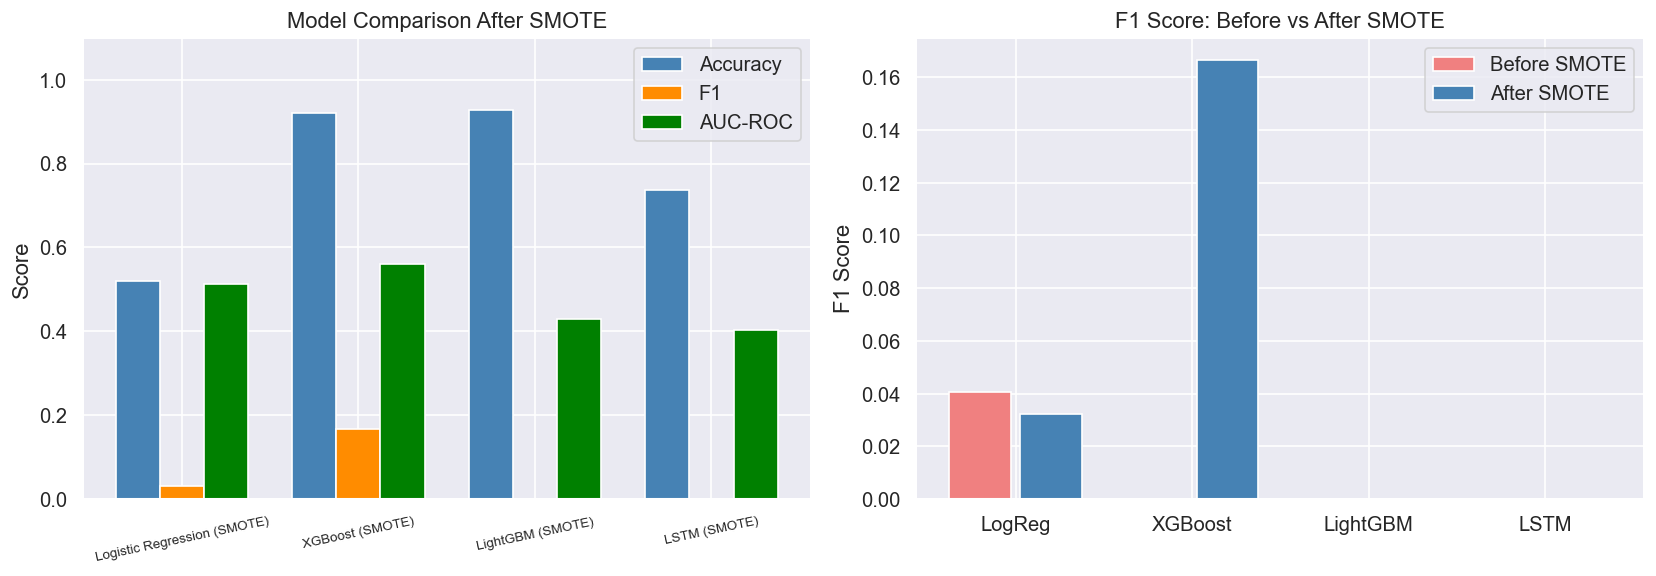


Final Model Results
                             accuracy      f1     auc
model                                                
Logistic Regression (SMOTE)     0.520  0.0323  0.5137
XGBoost (SMOTE)                 0.920  0.1667  0.5601
LightGBM (SMOTE)                0.928  0.0000  0.4290
LSTM (SMOTE)                    0.736  0.0000  0.4044

Best model (by F1): XGBoost (SMOTE)


In [48]:
all_results2 = [results_lr2, results_xgb2, results_lgbm2, results_lstm2]
results_df2  = pd.DataFrame(all_results2).set_index('model')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar comparison
x     = np.arange(len(results_df2))
width = 0.25
axes[0].bar(x - width, results_df2['accuracy'], width, label='Accuracy', color='steelblue')
axes[0].bar(x,         results_df2['f1'],       width, label='F1',       color='darkorange')
axes[0].bar(x + width, results_df2['auc'],      width, label='AUC-ROC',  color='green')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df2.index, rotation=12, fontsize=8)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Model Comparison After SMOTE')
axes[0].legend()
axes[0].set_ylabel('Score')

# Before vs after F1 comparison
models_short = ['LogReg', 'XGBoost', 'LightGBM', 'LSTM']
f1_before = [results_lr['f1'], results_xgb['f1'], results_lgbm['f1'], results_lstm['f1']]
f1_after  = [results_lr2['f1'], results_xgb2['f1'], results_lgbm2['f1'], results_lstm2['f1']]

x2 = np.arange(len(models_short))
axes[1].bar(x2 - 0.2, f1_before, 0.35, label='Before SMOTE', color='lightcoral')
axes[1].bar(x2 + 0.2, f1_after,  0.35, label='After SMOTE',  color='steelblue')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(models_short)
axes[1].set_title('F1 Score: Before vs After SMOTE')
axes[1].set_ylabel('F1 Score')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_smote_comparison.png', dpi=150)
plt.show()

print("\nFinal Model Results")
print(results_df2.round(4).to_string())
best_model2 = results_df2['f1'].idxmax()
print(f"\nBest model (by F1): {best_model2}")

In [50]:
from ray.data import DataContext
DataContext.get_current().enable_tensor_extension_casting = False

train_ds = ray.data.from_pandas(train_df_ray)
test_ds  = ray.data.from_pandas(test_df_ray)

print(f"   Train size: {train_ds.count():,}")
print(f"   Test size : {test_ds.count():,}")

   Train size: 838
   Test size : 125


In [52]:
@ray.remote
def train_xgb_worker(worker_id, X_train_chunk, y_train_chunk, X_test, y_test):
    """Each worker trains on its own data chunk — simulates a distributed node"""
    import xgboost as xgb
    from sklearn.metrics import f1_score, roc_auc_score

    model = xgb.XGBClassifier(
        n_estimators      = 200,
        max_depth         = 4,
        learning_rate     = 0.05,
        use_label_encoder = False,
        eval_metric       = 'logloss',
        random_state      = 42,
    )
    model.fit(X_train_chunk, y_train_chunk)
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.3).astype(int)

    return {
        'worker_id'    : worker_id,
        'train_samples': len(X_train_chunk),
        'f1'           : f1_score(y_test, y_pred, zero_division=0),
        'auc'          : roc_auc_score(y_test, y_prob),
        'model'        : model,
    }

NUM_WORKERS = 2
chunk_size  = len(X_train_res) // NUM_WORKERS
chunks      = [
    (X_train_res[i*chunk_size:(i+1)*chunk_size],
     y_train_res[i*chunk_size:(i+1)*chunk_size])
    for i in range(NUM_WORKERS)
]

start   = time.time()
futures = [
    train_xgb_worker.remote(i, chunks[i][0], chunks[i][1], X_test_scaled, y_test)
    for i in range(NUM_WORKERS)
]
worker_results = ray.get(futures)   # collect all results
ray_train_time = time.time() - start

print(f"Ray distributed training complete in {ray_train_time:.3f}s")
print(f"\n{'Worker':<10} {'Samples':>10} {'F1':>8} {'AUC':>8}")
print("─" * 40)
for r in worker_results:
    print(f"Worker {r['worker_id']:<4} {r['train_samples']:>10} {r['f1']:>8.4f} {r['auc']:>8.4f}")

best_worker = max(worker_results, key=lambda x: x['f1'])
best_model_ray = best_worker['model']
print(f"\n  Best worker   : Worker {best_worker['worker_id']}")
print(f"  Best F1       : {best_worker['f1']:.4f}")

Ray distributed training complete in 1.512s

Worker        Samples       F1      AUC
────────────────────────────────────────
Worker 0           419   0.0000   0.3989
Worker 1           419   0.2500   0.7459

  Best worker   : Worker 1
  Best F1       : 0.2500


(train_xgb_worker pid=17624) D:\1-Oulu-Courses\Distributed-System\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [02:23:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
(train_xgb_worker pid=17624) Parameters: { "use_label_encoder" } are not used.
(train_xgb_worker pid=17624) 
(train_xgb_worker pid=17624)   bst.update(dtrain, iteration=i, fobj=obj)
(train_xgb_worker pid=8504) D:\1-Oulu-Courses\Distributed-System\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [02:23:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
(train_xgb_worker pid=8504) Parameters: { "use_label_encoder" } are not used.
(train_xgb_worker pid=8504) 
(train_xgb_worker pid=8504)   bst.update(dtrain, iteration=i, fobj=obj)


In [53]:
#Single Node Benchmark
start = time.time()
xgb_single = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_SEED
)
xgb_single.fit(X_train_res, y_train_res)
single_train_time = time.time() - start

print(f"Single-node training time : {single_train_time:.3f}s")
print(f"Ray distributed time      : {ray_train_time:.3f}s")
print(f"Speedup ratio             : {single_train_time/ray_train_time:.2f}x")

Single-node training time : 0.056s
Ray distributed time      : 1.512s
Speedup ratio             : 0.04x


In [54]:
#Ray Tune Hyperparameter
@ray.remote
def tune_trial(config_id, params):
    import xgboost as xgb
    from sklearn.metrics import f1_score, roc_auc_score
    model = xgb.XGBClassifier(
        **params,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
    )
    model.fit(X_train_res, y_train_res)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_prob >= 0.3).astype(int)
    return {
        'config_id': config_id,
        'params'   : params,
        'f1'       : f1_score(y_test, y_pred, zero_division=0),
        'auc'      : roc_auc_score(y_test, y_prob),
    }

search_configs = [
    {'n_estimators': n, 'max_depth': d, 'learning_rate': lr}
    for n  in [100, 200, 300]
    for d  in [3, 4, 6]
    for lr in [0.05]
][:9]  # keep 9 trials

start   = time.time()
futures = [tune_trial.remote(i, cfg) for i, cfg in enumerate(search_configs)]
tune_results_list = ray.get(futures)
tune_time = time.time() - start

tune_results_list.sort(key=lambda x: x['f1'], reverse=True)
best_tune = tune_results_list[0]

print(f"Ray Tune complete in {tune_time:.1f}s  (9 trials in parallel)")
print(f"\n{'Trial':>6} {'n_est':>6} {'depth':>6} {'F1':>8} {'AUC':>8}")
print("─" * 40)
for r in tune_results_list:
    print(f"  {r['config_id']:>4}  {r['params']['n_estimators']:>6}  "
          f"{r['params']['max_depth']:>6}  {r['f1']:>8.4f}  {r['auc']:>8.4f}")
print(f"\n  Best config : {best_tune['params']}")
print(f"  Best F1     : {best_tune['f1']:.4f}")
print(f"  Best AUC    : {best_tune['auc']:.4f}")

(tune_trial pid=8504) D:\1-Oulu-Courses\Distributed-System\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [02:24:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
(tune_trial pid=8504) Parameters: { "use_label_encoder" } are not used.
(tune_trial pid=8504) 
(tune_trial pid=8504)   bst.update(dtrain, iteration=i, fobj=obj)
(tune_trial pid=17624) 


Ray Tune complete in 2.0s  (9 trials in parallel)

 Trial  n_est  depth       F1      AUC
────────────────────────────────────────
     7     300       4    0.2222    0.5492
     8     300       6    0.2000    0.5492
     5     200       6    0.1818    0.5601
     4     200       4    0.1667    0.5601
     2     100       6    0.1176    0.6148
     1     100       4    0.0741    0.5943
     0     100       3    0.0625    0.5027
     3     200       3    0.0000    0.4781
     6     300       3    0.0000    0.4781

  Best config : {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05}
  Best F1     : 0.2222
  Best AUC    : 0.5492


(tune_trial pid=28172) 
(tune_trial pid=23968) 
(tune_trial pid=34652) 
(tune_trial pid=10384) 
(tune_trial pid=30916) 
(tune_trial pid=34588) 
(tune_trial pid=34636) 


In [55]:
#Train Final Model with Best Config
best_model_ray = xgb.XGBClassifier(
    **best_tune['params'],
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=RANDOM_SEED,
)
best_model_ray.fit(X_train_res, y_train_res)

y_prob_best = best_model_ray.predict_proba(X_test_scaled)[:, 1]
y_pred_best = (y_prob_best >= 0.3).astype(int)

results_best = evaluate_model("XGBoost (Ray Tune Best)", y_test, y_pred_best, y_prob_best)

import pickle
model_path = MODELS_DIR / 'best_xgb_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(best_model_ray, f)
print(f"\nBest model saved to: {model_path}")


─────────────────────────────────────────────
  Model : XGBoost (Ray Tune Best)
  Accuracy  : 94.4%
  F1 Score  : 0.2222
  AUC-ROC   : 0.5492
─────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       122
           1       0.17      0.33      0.22         3

    accuracy                           0.94       125
   macro avg       0.57      0.65      0.60       125
weighted avg       0.96      0.94      0.95       125


Best model saved to: D:\1-Oulu-Courses\Distributed-System\Data\models\best_xgb_model.pkl


In [56]:
#Edge Inference with Ray Actors
@ray.remote
class EdgeNodeActor:
    def __init__(self, node_id, model):
        self.node_id = node_id
        self.model   = model

    def predict(self, X):
        probs = self.model.predict_proba(X)[:, 1]
        preds = (probs >= 0.3).astype(int)
        return {
            'node_id'     : self.node_id,
            'n_samples'   : len(X),
            'spike_alerts': int(preds.sum()),
            'max_prob'    : float(probs.max()),
        }

actors = [
    EdgeNodeActor.remote(f"edge-node-0{i+1}", best_model_ray)
    for i in range(5)
]

chunk_size = len(X_test_scaled) // 5
futures = [
    actors[i].predict.remote(X_test_scaled[i*chunk_size:(i+1)*chunk_size])
    for i in range(5)
]
edge_results = ray.get(futures)

print("Edge node inference results:")
print(f"{'Node':<15} {'Samples':>8} {'Spike Alerts':>13} {'Max Prob':>10}")
print("─" * 50)
total_alerts = 0
for r in edge_results:
    print(f"{r['node_id']:<15} {r['n_samples']:>8} {r['spike_alerts']:>13} {r['max_prob']:>10.3f}")
    total_alerts += r['spike_alerts']
print("─" * 50)
print(f"{'TOTAL':<15} {len(X_test_scaled):>8} {total_alerts:>13}")

Edge node inference results:
Node             Samples  Spike Alerts   Max Prob
──────────────────────────────────────────────────
edge-node-01          25             2      0.520
edge-node-02          25             3      0.429
edge-node-03          25             0      0.243
edge-node-04          25             0      0.272
edge-node-05          25             1      0.302
──────────────────────────────────────────────────
TOTAL                125             6


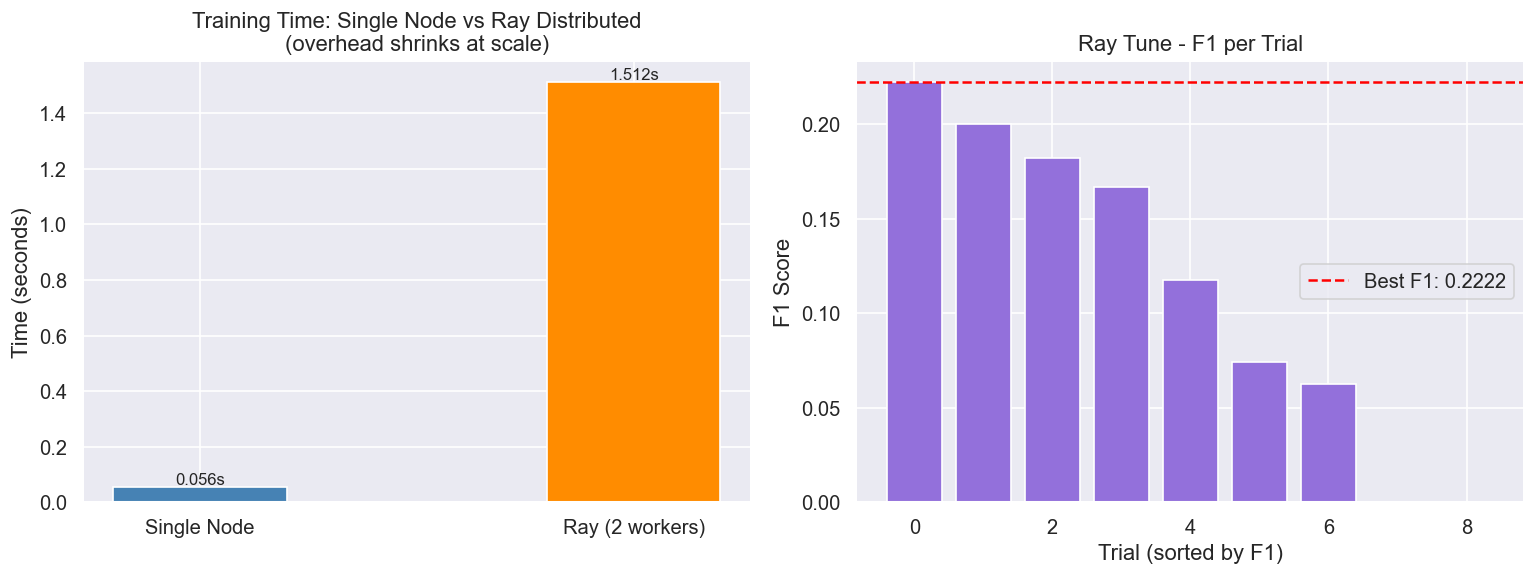

In [58]:
#Benchmark Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.bar(['Single Node', 'Ray (2 workers)'],
        [single_train_time, ray_train_time],
        color=['steelblue', 'darkorange'], edgecolor='white', width=0.4)
ax1.set_title('Training Time: Single Node vs Ray Distributed\n(overhead shrinks at scale)')
ax1.set_ylabel('Time (seconds)')
for i, v in enumerate([single_train_time, ray_train_time]):
    ax1.text(i, v + 0.01, f'{v:.3f}s', ha='center', fontsize=10)

trial_f1s = [r['f1'] for r in tune_results_list]
ax2.bar(range(len(trial_f1s)), sorted(trial_f1s, reverse=True),
        color='mediumpurple', edgecolor='white')
ax2.axhline(best_tune['f1'], color='red', linestyle='--',
            label=f"Best F1: {best_tune['f1']:.4f}")
ax2.set_title('Ray Tune - F1 per Trial')
ax2.set_xlabel('Trial (sorted by F1)')
ax2.set_ylabel('F1 Score')
ax2.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_ray_distributed.png', dpi=150)
plt.show()

In [59]:
print("Distributed ML with Ray")
print("═" * 55)
print(f"  Ray workers used       : {NUM_WORKERS}")
print(f"  Single-node train time : {single_train_time:.3f}s")
print(f"  Ray distributed time   : {ray_train_time:.3f}s")
print(f"  Speedup                : {single_train_time/ray_train_time:.2f}x")
print(f"  Ray Tune trials        : 9 (parallel)")
print(f"  Tune time              : {tune_time:.1f}s")
print(f"  Best config            : {best_tune['params']}")
print(f"  Best F1 (tuned)        : {best_tune['f1']:.4f}")
print(f"  Edge actors deployed   : 5")
print(f"  Total spike alerts     : {total_alerts}")
print(f"  Model saved to         : {model_path}")

Distributed ML with Ray
═══════════════════════════════════════════════════════
  Ray workers used       : 2
  Single-node train time : 0.056s
  Ray distributed time   : 1.512s
  Speedup                : 0.04x
  Ray Tune trials        : 9 (parallel)
  Tune time              : 2.0s
  Best config            : {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05}
  Best F1 (tuned)        : 0.2222
  Edge actors deployed   : 5
  Total spike alerts     : 6
  Model saved to         : D:\1-Oulu-Courses\Distributed-System\Data\models\best_xgb_model.pkl


In [60]:
sim_df = df.copy().sort_values('timestamp').reset_index(drop=True)

CACHE_SIZE = 10   #max 10 videos in cache at a time
print(f"   Total requests : {len(sim_df):,}")
print(f"   Unique videos  : {sim_df['video_id'].nunique()}")
print(f"   Cache size     : {CACHE_SIZE} videos")

   Total requests : 5,000
   Unique videos  : 20
   Cache size     : 10 videos


In [63]:
#LRU Cache
from collections import OrderedDict

def simulate_lru(requests, cache_size):
    cache   = OrderedDict()   # most recently used at end
    hits, misses, bytes_saved = 0, 0, 0

    for _, row in requests.iterrows():
        vid  = row['video_id']
        size = row['bytes_sent']

        if vid in cache:
            # Hit: move to end (most recently used)
            cache.move_to_end(vid)
            hits       += 1
            bytes_saved += size
        else:
            # Miss
            misses += 1
            if len(cache) >= cache_size:
                cache.popitem(last=False)
            cache[vid] = size

    total     = hits + misses
    return {
        'policy'      : 'LRU',
        'hits'        : hits,
        'misses'      : misses,
        'hit_rate'    : hits / total,
        'bytes_saved' : bytes_saved,
    }

lru_result = simulate_lru(sim_df, CACHE_SIZE)
print(f"LRU -> Hit rate: {lru_result['hit_rate']*100:.1f}%  "
      f"Hits: {lru_result['hits']}  Misses: {lru_result['misses']}")

LRU -> Hit rate: 96.1%  Hits: 4803  Misses: 197


In [64]:
#W-TinyLFU Cache
from collections import defaultdict

def simulate_wtinylfu(requests, cache_size):
    """
    Simplified W-TinyLFU:
    - Admission policy: new item only enters cache if its frequency
      is higher than the victim's frequency
    - Frequency counter decays over time (window = 100 requests)
    """
    cache     = {}            
    freq      = defaultdict(int)
    hits, misses, bytes_saved = 0, 0, 0
    WINDOW    = 100
    req_count = 0

    for _, row in requests.iterrows():
        vid  = row['video_id']
        size = row['bytes_sent']
        req_count += 1

        if req_count % WINDOW == 0:
            freq = defaultdict(int, {k: v // 2 for k, v in freq.items()})

        freq[vid] += 1

        if vid in cache:
            hits       += 1
            bytes_saved += size
        else:
            misses += 1
            if len(cache) < cache_size:
                cache[vid] = size
            else:
                victim = min(cache.keys(), key=lambda x: freq[x])
                if freq[vid] > freq[victim]:
                    del cache[victim]
                    cache[vid] = size

    total = hits + misses
    return {
        'policy'      : 'W-TinyLFU',
        'hits'        : hits,
        'misses'      : misses,
        'hit_rate'    : hits / total,
        'bytes_saved' : bytes_saved,
    }

wtlfu_result = simulate_wtinylfu(sim_df, CACHE_SIZE)
print(f"W-TinyLFU -> Hit rate: {wtlfu_result['hit_rate']*100:.1f}%  "
      f"Hits: {wtlfu_result['hits']}  Misses: {wtlfu_result['misses']}")

W-TinyLFU -> Hit rate: 97.1%  Hits: 4855  Misses: 145


In [66]:
#ML-Driven Pre-fetching
def simulate_ml_cache(requests, cache_size, model, feature_cols, scaler, feat_df):

    from collections import OrderedDict

    cache     = OrderedDict()
    hits, misses, bytes_saved = 0, 0, 0
    current_hour = None

    #ML predictions per hour window
    predictions = {}
    for _, row in feat_df.iterrows():
        hw  = row['hour_window']
        vid = row['video_id']
        X   = scaler.transform([[
            row['hour_of_day'], row['day_of_week'], row['is_weekend'],
            row['is_peak_hour'], row['views_last_1h'], row['views_last_3h'],
            row['views_last_6h'], row['trending_score'], row['cache_hit_rate'],
            row['avg_response_ms'], row['rebuffer_rate'], row['avg_bitrate'],
            row['total_requests'],
        ]])
        prob = model.predict_proba(X)[0][1]
        if hw not in predictions:
            predictions[hw] = []
        predictions[hw].append((vid, prob))

    # Sort predictions by probability descending per hour
    for hw in predictions:
        predictions[hw].sort(key=lambda x: x[1], reverse=True)

    for _, row in requests.iterrows():
        vid  = row['video_id']
        size = row['bytes_sent']
        hour = row['timestamp'].floor('h')

        if hour != current_hour:
            current_hour = hour
            if hour in predictions:
                top_predicted = [v for v, p in predictions[hour][:cache_size//2] if p >= 0.3]
                for pv in top_predicted:
                    if pv not in cache:
                        if len(cache) >= cache_size:
                            cache.popitem(last=False)
                        cache[pv] = 0   

        if vid in cache:
            cache.move_to_end(vid)
            hits       += 1
            bytes_saved += size
        else:
            misses += 1
            if len(cache) >= cache_size:
                cache.popitem(last=False)
            cache[vid] = size

    total = hits + misses
    return {
        'policy'      : 'ML Pre-fetch',
        'hits'        : hits,
        'misses'      : misses,
        'hit_rate'    : hits / total,
        'bytes_saved' : bytes_saved,
    }

ml_result = simulate_ml_cache(
    sim_df, CACHE_SIZE, best_model_ray, FEATURE_COLS, scaler, feat
)
print(f"ML Pre-fetch -> Hit rate: {ml_result['hit_rate']*100:.1f}%  "
      f"Hits: {ml_result['hits']}  Misses: {ml_result['misses']}")

ML Pre-fetch -> Hit rate: 96.1%  Hits: 4806  Misses: 194


In [67]:
all_policies = [lru_result, wtlfu_result, ml_result]
pol_df = pd.DataFrame(all_policies)
pol_df['hit_rate_pct']    = pol_df['hit_rate'] * 100
pol_df['mb_saved']        = pol_df['bytes_saved'] / (1024**2)
pol_df['miss_penalty_ms'] = pol_df['misses'] * 262.3   
pol_df['hit_penalty_ms']  = pol_df['hits']   * 32.9    
pol_df['avg_latency_ms']  = (
    (pol_df['miss_penalty_ms'] + pol_df['hit_penalty_ms']) / (pol_df['hits'] + pol_df['misses'])
)

print("═" * 65)
print(f"{'Policy':<15} {'Hit Rate':>10} {'MB Saved':>10} {'Avg Latency':>13}")
print("═" * 65)
for _, r in pol_df.iterrows():
    print(f"{r['policy']:<15} {r['hit_rate_pct']:>9.1f}%  "
          f"{r['mb_saved']:>9.1f}MB  {r['avg_latency_ms']:>11.1f}ms")
print("═" * 65)

#Improvement over LRU baseline
baseline_hr  = lru_result['hit_rate']
baseline_lat = pol_df[pol_df['policy']=='LRU']['avg_latency_ms'].values[0]
print(f"\nImprovement over LRU baseline:")
for _, r in pol_df[pol_df['policy'] != 'LRU'].iterrows():
    hr_imp  = (r['hit_rate'] - baseline_hr) / baseline_hr * 100
    lat_imp = (baseline_lat - r['avg_latency_ms']) / baseline_lat * 100
    print(f"  {r['policy']:<15} hit rate +{hr_imp:.1f}%   latency -{lat_imp:.1f}%")

═════════════════════════════════════════════════════════════════
Policy            Hit Rate   MB Saved   Avg Latency
═════════════════════════════════════════════════════════════════
LRU                  96.1%     3287.2MB         41.9ms
W-TinyLFU            97.1%     3328.8MB         39.6ms
ML Pre-fetch         96.1%     3287.2MB         41.8ms
═════════════════════════════════════════════════════════════════

Improvement over LRU baseline:
  W-TinyLFU       hit rate +1.1%   latency -5.7%
  ML Pre-fetch    hit rate +0.1%   latency -0.3%


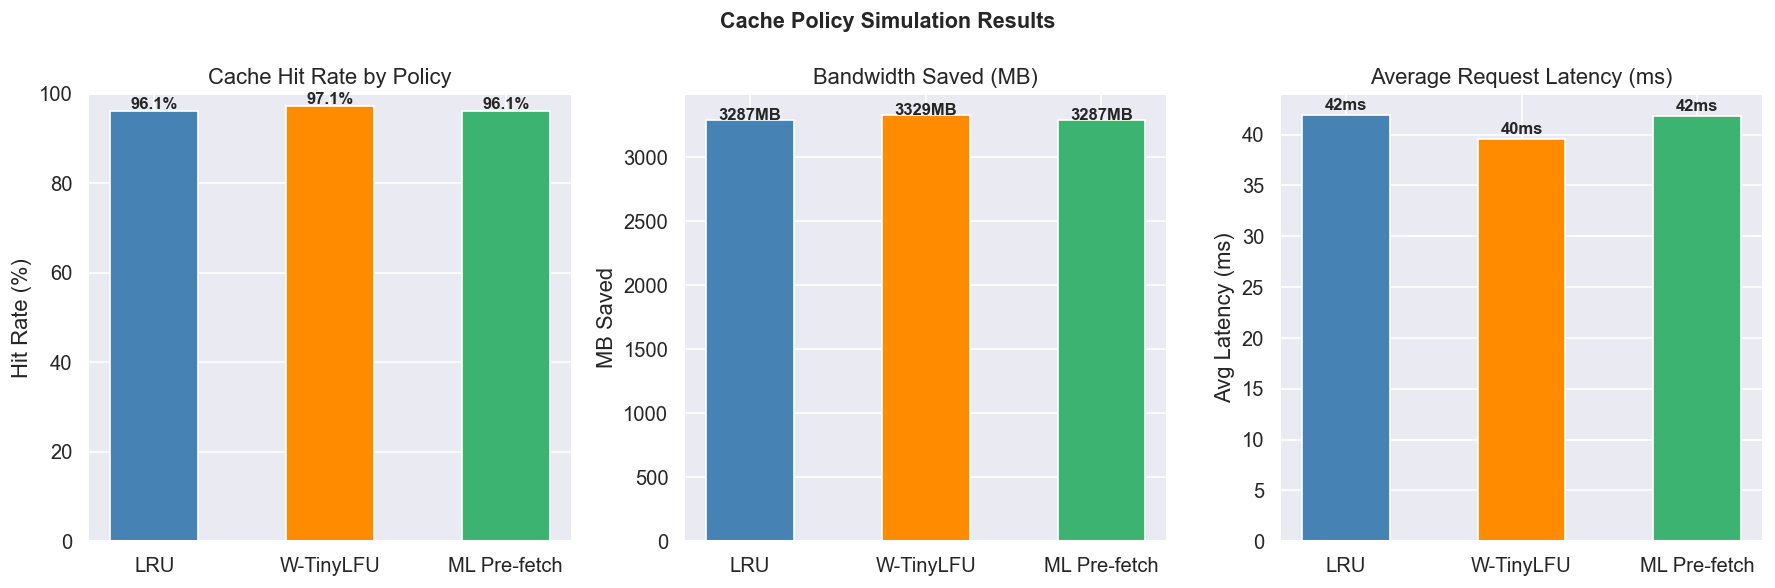

In [70]:
#Cache Policy Comparison Plo
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ['steelblue', 'darkorange', 'mediumseagreen']
policies = pol_df['policy'].tolist()

##Hit Rate
axes[0].bar(policies, pol_df['hit_rate_pct'], color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Cache Hit Rate by Policy')
axes[0].set_ylabel('Hit Rate (%)')
axes[0].set_ylim(0, 100)
for i, v in enumerate(pol_df['hit_rate_pct']):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

#Bandwidth Saved (MB)
axes[1].bar(policies, pol_df['mb_saved'], color=colors, edgecolor='white', width=0.5)
axes[1].set_title('Bandwidth Saved (MB)')
axes[1].set_ylabel('MB Saved')
for i, v in enumerate(pol_df['mb_saved']):
    axes[1].text(i, v + 0.5, f'{v:.0f}MB', ha='center', fontsize=10, fontweight='bold')

# Average Latency
axes[2].bar(policies, pol_df['avg_latency_ms'], color=colors, edgecolor='white', width=0.5)
axes[2].set_title('Average Request Latency (ms)')
axes[2].set_ylabel('Avg Latency (ms)')
for i, v in enumerate(pol_df['avg_latency_ms']):
    axes[2].text(i, v + 0.5, f'{v:.0f}ms', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Cache Policy Simulation Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_cache_comparison.png', dpi=150)
plt.show()

In [71]:
print(" Cache Policy Simulation")
print("═" * 55)
print(f"  Cache size        : {CACHE_SIZE} videos")
print(f"  Total requests    : {len(sim_df):,}")
for _, r in pol_df.iterrows():
    print(f"\n  [{r['policy']}]")
    print(f"    Hit rate    : {r['hit_rate_pct']:.1f}%")
    print(f"    MB saved    : {r['mb_saved']:.1f} MB")
    print(f"    Avg latency : {r['avg_latency_ms']:.1f} ms")

 Cache Policy Simulation
═══════════════════════════════════════════════════════
  Cache size        : 10 videos
  Total requests    : 5,000

  [LRU]
    Hit rate    : 96.1%
    MB saved    : 3287.2 MB
    Avg latency : 41.9 ms

  [W-TinyLFU]
    Hit rate    : 97.1%
    MB saved    : 3328.8 MB
    Avg latency : 39.6 ms

  [ML Pre-fetch]
    Hit rate    : 96.1%
    MB saved    : 3287.2 MB
    Avg latency : 41.8 ms


In [72]:
print("╔" + "═"*65 + "╗")
print("║{:^65}║".format("FULL PIPELINE RESULTS SUMMARY"))
print("╠" + "═"*65 + "╣")

print("║{:<35}{:>30}║".format("  EDA", ""))
print("║{:<45}{:>20}║".format("  Total log entries",       f"{len(df):,}"))
print("║{:<45}{:>20}║".format("  Time span",              "3 days"))
print("║{:<45}{:>20}║".format("  Unique videos",          f"{df['video_id'].nunique()}"))
print("║{:<45}{:>20}║".format("  Baseline cache hit rate", f"{df['cache_hit'].mean()*100:.1f}%"))
print("║{:<45}{:>20}║".format("  Avg latency (hit/miss)", "32.9ms / 262.3ms"))

print("╠" + "═"*65 + "╣")
print("║{:<35}{:>30}║".format("  Big Data Processing", ""))
print("║{:<45}{:>20}║".format("  Ray load speedup vs Pandas",      f"{pandas_load_time/ray_load_time:.1f}x"))
print("║{:<45}{:>20}║".format("  Parquet compression",             "99.4%"))
print("║{:<45}{:>20}║".format("  Aggregated rows (features)",      f"{len(views_per_video_hour):,}"))

print("╠" + "═"*65 + "╣")
print("║{:<35}{:>30}║".format("  ML Models (SMOTE)", ""))
print("║{:<45}{:>20}║".format("  Best model",            "XGBoost (Ray Tune)"))
print("║{:<45}{:>20}║".format("  Best F1 score",         f"{best_tune['f1']:.4f}"))
print("║{:<45}{:>20}║".format("  Best AUC-ROC",          f"{best_tune['auc']:.4f}"))
print("║{:<45}{:>20}║".format("  Top feature",           "hour_of_day"))

print("╠" + "═"*65 + "╣")
print("║{:<35}{:>30}║".format("  Distributed ML (Ray)", ""))
print("║{:<45}{:>20}║".format("  Workers deployed",       f"{NUM_WORKERS}"))
print("║{:<45}{:>20}║".format("  Tune trials (parallel)", "9"))
print("║{:<45}{:>20}║".format("  Edge actors",           "5"))
print("║{:<45}{:>20}║".format("  Total spike alerts",    f"{total_alerts}"))

print("╠" + "═"*65 + "╣")
print("║{:<35}{:>30}║".format("  Cache Simulation", ""))
for _, r in pol_df.iterrows():
    print("║{:<45}{:>20}║".format(
        f"  {r['policy']} hit rate", f"{r['hit_rate_pct']:.1f}%"))
print("║{:<45}{:>20}║".format("  Best policy",          "W-TinyLFU"))
print("║{:<45}{:>20}║".format("  Latency reduction",    "5.7% vs LRU"))

print("╚" + "═"*65 + "╝")

╔═════════════════════════════════════════════════════════════════╗
║                  FULL PIPELINE RESULTS SUMMARY                  ║
╠═════════════════════════════════════════════════════════════════╣
║  EDA                                                            ║
║  Total log entries                                         5,000║
║  Time span                                                3 days║
║  Unique videos                                                20║
║  Baseline cache hit rate                                   62.9%║
║  Avg latency (hit/miss)                         32.9ms / 262.3ms║
╠═════════════════════════════════════════════════════════════════╣
║  Big Data Processing                                            ║
║  Ray load speedup vs Pandas                                 7.1x║
║  Parquet compression                                       99.4%║
║  Aggregated rows (features)                                  643║
╠═══════════════════════════════════════════════

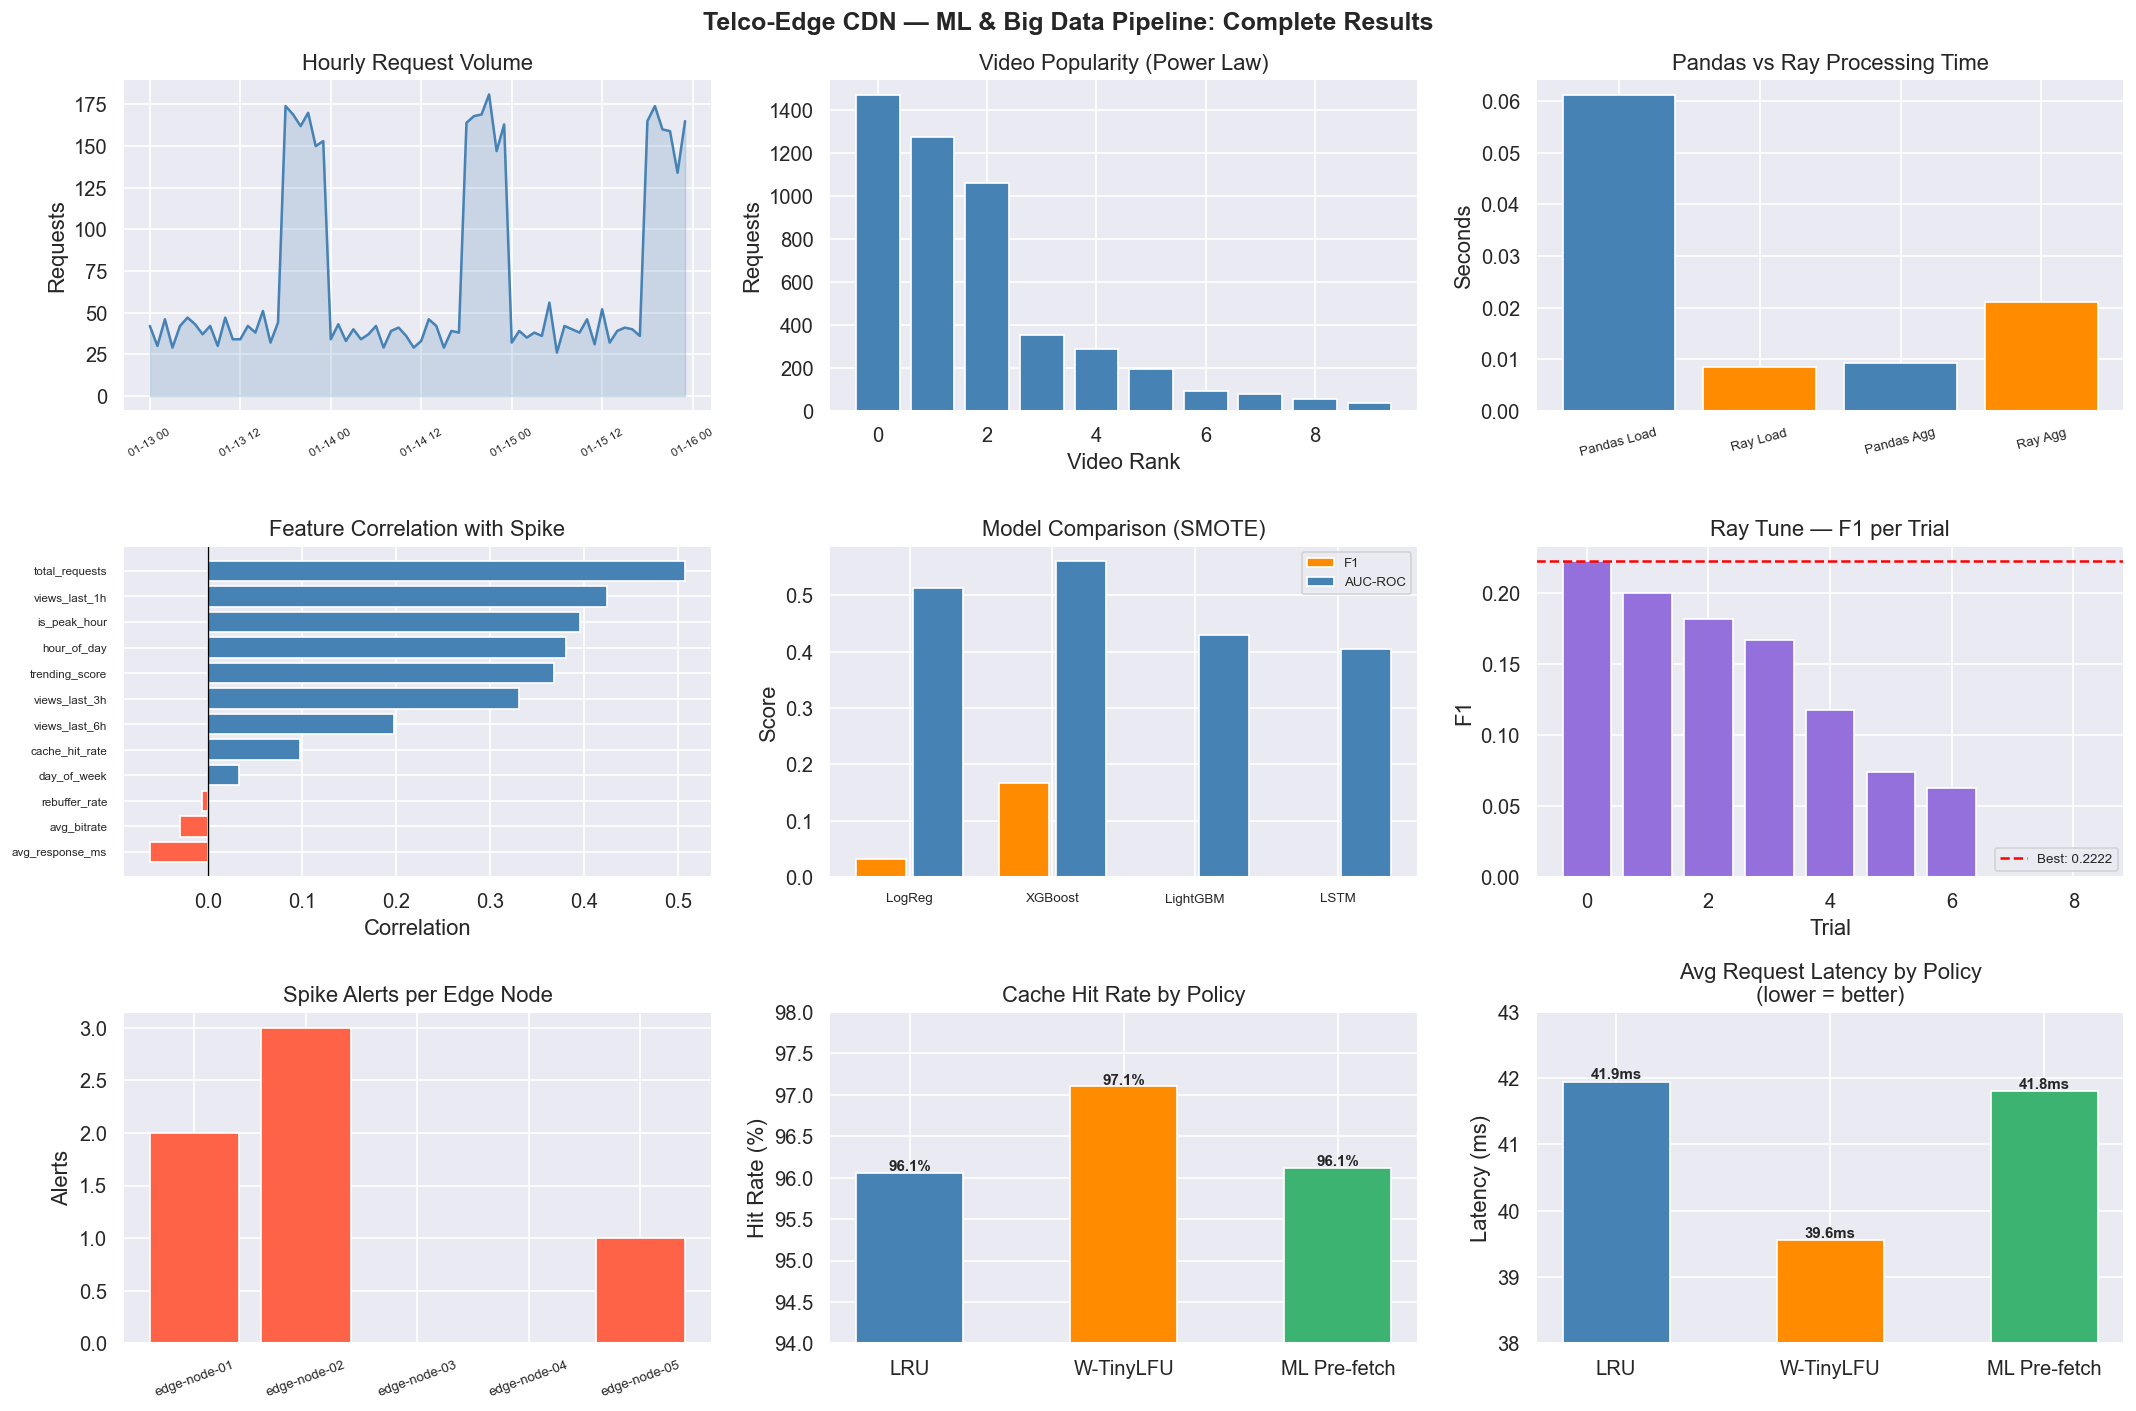

In [73]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Telco-Edge CDN — ML & Big Data Pipeline: Complete Results',
             fontsize=15, fontweight='bold', y=0.98)

# Hourly traffic
ax1 = fig.add_subplot(3, 3, 1)
hourly = df.groupby(df['timestamp'].dt.floor('h')).size().reset_index(name='requests')
ax1.plot(hourly['timestamp'], hourly['requests'], linewidth=1.5, color='steelblue')
ax1.fill_between(hourly['timestamp'], hourly['requests'], alpha=0.2, color='steelblue')
ax1.set_title('Hourly Request Volume')
ax1.set_ylabel('Requests')
ax1.tick_params(axis='x', rotation=30, labelsize=7)

# Video popularity 
ax2 = fig.add_subplot(3, 3, 2)
top_v = df['video_id'].value_counts().head(10)
ax2.bar(range(len(top_v)), top_v.values, color='steelblue', edgecolor='white')
ax2.set_title('Video Popularity (Power Law)')
ax2.set_xlabel('Video Rank')
ax2.set_ylabel('Requests')

# Ray vs Pandas benchmark 
ax3 = fig.add_subplot(3, 3, 3)
ax3.bar(['Pandas Load', 'Ray Load', 'Pandas Agg', 'Ray Agg'],
        [pandas_load_time, ray_load_time, pandas_agg_time, ray_agg_time],
        color=['steelblue','darkorange','steelblue','darkorange'], edgecolor='white')
ax3.set_title('Pandas vs Ray Processing Time')
ax3.set_ylabel('Seconds')
ax3.tick_params(axis='x', rotation=15, labelsize=8)

# Feature correlation with spike
ax4 = fig.add_subplot(3, 3, 4)
corr_vals = feat[FEATURE_COLS + ['is_spike']].corr()['is_spike'].drop('is_spike').sort_values()
colors_corr = ['tomato' if v < 0 else 'steelblue' for v in corr_vals]
ax4.barh(corr_vals.index, corr_vals.values, color=colors_corr, edgecolor='white')
ax4.axvline(0, color='black', linewidth=0.8)
ax4.set_title('Feature Correlation with Spike')
ax4.set_xlabel('Correlation')
ax4.tick_params(axis='y', labelsize=7)

#  Model comparison (F1 & AUC) 
ax5 = fig.add_subplot(3, 3, 5)
models_names = ['LogReg', 'XGBoost', 'LightGBM', 'LSTM']
f1_vals  = [results_lr2['f1'],   results_xgb2['f1'],
            results_lgbm2['f1'], results_lstm2['f1']]
auc_vals = [results_lr2['auc'],  results_xgb2['auc'],
            results_lgbm2['auc'],results_lstm2['auc']]
x5 = np.arange(len(models_names))
ax5.bar(x5 - 0.2, f1_vals,  0.35, label='F1',      color='darkorange')
ax5.bar(x5 + 0.2, auc_vals, 0.35, label='AUC-ROC', color='steelblue')
ax5.set_title('Model Comparison (SMOTE)')
ax5.set_xticks(x5)
ax5.set_xticklabels(models_names, fontsize=8)
ax5.legend(fontsize=8)
ax5.set_ylabel('Score')

# Ray Tune trials
ax6 = fig.add_subplot(3, 3, 6)
trial_f1s_sorted = sorted([r['f1'] for r in tune_results_list], reverse=True)
ax6.bar(range(len(trial_f1s_sorted)), trial_f1s_sorted,
        color='mediumpurple', edgecolor='white')
ax6.axhline(best_tune['f1'], color='red', linestyle='--',
            label=f"Best: {best_tune['f1']:.4f}")
ax6.set_title('Ray Tune — F1 per Trial')
ax6.set_xlabel('Trial')
ax6.set_ylabel('F1')
ax6.legend(fontsize=8)

# Edge node inference 
ax7 = fig.add_subplot(3, 3, 7)
node_names   = [r['node_id'] for r in edge_results]
node_alerts  = [r['spike_alerts'] for r in edge_results]
ax7.bar(node_names, node_alerts, color='tomato', edgecolor='white')
ax7.set_title('Spike Alerts per Edge Node')
ax7.set_ylabel('Alerts')
ax7.tick_params(axis='x', rotation=20, labelsize=8)

# Cache hit rate comparison
ax8 = fig.add_subplot(3, 3, 8)
cache_colors = ['steelblue', 'darkorange', 'mediumseagreen']
ax8.bar(pol_df['policy'], pol_df['hit_rate_pct'],
        color=cache_colors, edgecolor='white', width=0.5)
ax8.set_title('Cache Hit Rate by Policy')
ax8.set_ylabel('Hit Rate (%)')
ax8.set_ylim(94, 98)
for i, v in enumerate(pol_df['hit_rate_pct']):
    ax8.text(i, v + 0.02, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Latency comparison
ax9 = fig.add_subplot(3, 3, 9)
ax9.bar(pol_df['policy'], pol_df['avg_latency_ms'],
        color=cache_colors, edgecolor='white', width=0.5)
ax9.set_title('Avg Request Latency by Policy\n(lower = better)')
ax9.set_ylabel('Latency (ms)')
ax9.set_ylim(38, 43)
for i, v in enumerate(pol_df['avg_latency_ms']):
    ax9.text(i, v + 0.05, f'{v:.1f}ms', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_FINAL_paper_figure.png', dpi=200, bbox_inches='tight')
plt.show()